# [이론] 의사결정나무와 앙상블

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🌳 의사결정나무와 앙상블 — 여러 모델을 모으면 강해진다

## — 한 그루의 나무에서, 숲과 부스팅으로

> **AI 데이터 인텔리전스 과정** · **필수 머신러닝** 모듈

---

## 📋 학습 목표

이 노트북을 끝내고 나면 여러분은:

1. **의사결정나무**가 질문(분기)으로 데이터를 나누는 원리와 분할 기준(**지니·엔트로피**), 그리고 **과적합·가지치기**를 설명할 수 있습니다.
2. **배깅(랜덤포레스트)** 과 **부스팅(AdaBoost·GBM·XGBoost)** 이 약한 모델을 모아 강하게 만드는 *서로 다른 두 전략*임을 비교할 수 있습니다.
3. **RandomForest·XGBoost**로 분류/회귀를 학습하고, **피처 중요도**를 해석할 수 있습니다.
4. **단일 트리 대비 앙상블의 성능 향상**을 직접 비교해 확인할 수 있습니다.
5. 단일 트리의 **해석력**과 앙상블의 **성능** 사이 **트레이드오프**를 인식할 수 있습니다.

## 📚 학습 목차

| Part | 내용 | 이 파트에서 답할 질문 | ⏱ 예상 |
|------|------|----------------------| --- |
| 0 | 오늘의 여정 | 새 개념 전에, 왜 트리인가? | 25분 |
| 1 | 의사결정나무 — 스무고개로 나누기 | 트리는 어떤 기준으로 질문을 고르나? | 40분 |
| 2 | 트리는 왜 과적합할까 — 가지치기 | 한 그루 나무의 약점은 무엇인가? | 25분 |
| 3 | 숲을 이루다 — 배깅과 랜덤포레스트 | 나무를 여러 그루 모으면 왜 나아지나? | 40분 |
| 4 | 오차를 보정하며 배운다 — 부스팅 | 순차적으로 실수를 고친다는 게 뭔가? | 50분 |
| 5 | 단일 vs 앙상블 · 피처 중요도 | 성능을 얻고 무엇을 내주나? | 40분 |
| 정리 | 핵심 요약 · 실습 안내 | 무엇을 모델 카드에 남기나? | 20분 |
| 과제 | 오늘의 과제 · 미니과제 | 모델 카드 v2를 어떻게 쓰나? | 5분 |

*⏱ 예상 시간은 참고용 안내입니다. 학습 속도는 사람마다 다릅니다 — 여러분의 속도로 가면 됩니다.*

자, 시작해볼까요?

# Part 0. 오늘의 여정

우리는 이전 시간에 이어 구독 서비스 **모두플레이(ModuPlay)** 의 데이터 분석가입니다. CS팀의 숙제는 그대로입니다 — *"이탈할 것 같은 고객을 미리 골라내자."* 이전 시간엔 **로지스틱 회귀**로 첫 답을 냈습니다. 오늘은 **다른 종류의 패턴을 보는 모델** — 의사결정나무와 앙상블로 두 번째 답을 만듭니다.

## 🔁 지난 시간 복습

트리·앙상블로 넘어가기 전에, 앞서 배운 핵심을 30초만 되짚어 봅시다.

- **지도학습**: (입력 X, 정답 y) 쌍으로 규칙을 배워 새 데이터의 답을 예측. y가 숫자면 **회귀**, 범주면 **분류**.
- **선형 회귀**: 직선으로 숫자 예측. 평가는 **MSE(작을수록)·R²(1에 가까울수록)**.
- **로지스틱 회귀**: 시그모이드로 확률 → 0.5 임계값으로 분류. 평가는 **정확도**.
- **정직한 평가**: `train_test_split`으로 나누고, **테스트 점수**와 **학습-테스트 격차(과적합)** 를 함께 본다. **베이스라인보다 나은가?** 를 확인.

> 💡 이 네 가지(특히 *과적합 점검*과 *베이스라인 비교*)는 오늘도 그대로 씁니다. **골격은 똑같고, 그 위에 얹는 모델만 바뀝니다.**

## 왜 트리인가 — 직선이 놓치는 패턴

어제 우리는 모델을 두 개 배웠지만, 사실 **심장은 하나**였습니다. 선형 회귀도 로지스틱 회귀도 안에서는 똑같은 **선형결합(Linear Combination)** — 즉 직선 — 을 계산합니다: $z = w_1x_1 + w_2x_2 + \cdots + b$. 선형 회귀는 이 $z$를 그대로 답으로 내고, 로지스틱 회귀는 시그모이드라는 S자 스위치에 한 번 통과시켜 확률로 바꿀 뿐입니다. 결정경계가 직선이었던 이유입니다.

그래서 둘은 같은 가정을 공유합니다 — **각 피처는 자기 계수 하나로만 말한다.** 방향은 하나뿐이고(계수가 양수면 그 피처는 어디서나 확률을 올리기만 합니다), 효과들은 서로 **더해질 뿐 곱해지지 않습니다.** 어제 계수를 오즈비 "배수"로 해석할 수 있었던 것도 이 가정 덕분입니다 — 계수 하나 = 효과 하나.

그런데 현실의 이탈은 자주 **조합**으로 일어납니다.

> *"가입한 지 **3개월도 안 됐는데** 문의가 벌써 **3건 이상**인 고객은 대부분 떠난다. 그런데 3년 차 고객의 문의 3건은 아무 신호도 아니다."*

이 규칙에서 문의 건수의 효과는 가입 기간에 따라 **정반대**가 됩니다 — 계수 하나로는 표현할 수 없습니다. 로지스틱 회귀로 잡으려면 사람이 교차항(Interaction Term)을 손으로 만들어 넣어야 합니다. 오늘 배울 **의사결정나무**는 다릅니다 — "가입 3개월 미만인가?" → "문의 3건 이상인가?" 두 번의 질문(분기)으로 **이런 조합을 데이터에서 스스로 찾아냅니다.** 오늘부터 우리는 **직선의 가족을 떠나 질문의 가족**을 만납니다.

시작하기 전에 두 가지를 정직하게 말해 두겠습니다.

1. **트리가 항상 이기는 것은 아닙니다.** 패턴이 실제로 직선에 가까운 데이터라면 로지스틱 회귀가 더 낫습니다. 그래서 오늘도 어제처럼 **베이스라인부터 놓고 비교표로 확인**합니다 — 오후 [실습]에서 실제 비즈니스 데이터에 직접 얹어 판정합니다.
2. **오늘 만드는 트리는 오늘로 끝나지 않습니다.** 이 모듈의 남은 날들이 오늘 위에 서 있습니다.

| 앞으로 배울 것 | 오늘이 필요한 이유 |
| --- | --- |
| 과적합·교차검증 (다음 시간) | 과적합이 *태어나는 장면*을 트리의 `max_depth` 손잡이로 직접 만들어 봅니다 |
| 피처·Pipeline 이후의 [실습] | 누적 포트폴리오의 주력 모델이 오늘 배우는 **랜덤포레스트**입니다 |
| 모델 해석·SHAP | 오늘 앙상블은 성능을 얻는 대신 **해석력을 내줍니다** — 그걸 되찾는 도구(SHAP)가 트리 계열 전용입니다 |

## 🗺️ 오늘 배울 것

```text
[Part 1] 의사결정나무   →  질문으로 나누기 (지니·정보획득)
   ↓ 한 그루는 불안정·과적합
[Part 2] 가지치기        →  깊이를 제한해 과적합 억제
   ↓ 그럼 여러 그루를 모으면?
[Part 3] 배깅·랜덤포레스트 →  독립적인 나무들의 '투표' (분산↓)
   ↓ 다른 전략은 없을까?
[Part 4] 부스팅(AdaBoost·GBM·XGBoost) → 오차를 순차 보정 (편향↓)
   ↓
[Part 5] 단일 vs 앙상블 · 피처 중요도 (성능 vs 해석력)
```

> 🧭 **한눈에 보기:** 오늘의 다섯 Part는 **하나의 질문을 계속 밀고 나갑니다** — *"한 그루로 부족하면 어떻게 하지?"* Part 1~2가 한 그루의 힘과 한계를 보여주고, Part 3(배깅)과 Part 4(부스팅)가 **서로 다른 두 답**을 내놓습니다. 배깅은 *여러 그루를 동시에 키워 투표*하고, 부스팅은 *한 그루씩 순차로 실수를 고칩니다*. Part 5는 그 대가로 무엇을 내줬는지(해석력)를 정산합니다.

## 왜 LLM이 아니라 XGBoost인가

방금 "왜 어제의 로지스틱 회귀만으로 부족한가"에 답했습니다. 그런데 요즘은 반대 방향의 질문도 받습니다 — 기왕 바꿀 거면 왜 최신 AI가 아닌가?

생성형 AI가 모든 것을 하는 시대에, 왜 2020년대 초에 나온 트리 모델을 배울까요? 실무에서 이 질문을 받으면 답할 수 있어야 합니다.

답은 **데이터의 형태**에 있습니다.

| 데이터 형태 | 예 | 현재 최강 |
| --- | --- | --- |
| 이미지·음성·자연어 | 사진, 통화 녹음, 리뷰 텍스트 | **딥러닝·LLM** |
| **표(Table) 형태 정형 데이터** | 고객 명단, 거래 기록, 센서 로그 | **트리 앙상블** (랜덤포레스트·XGBoost) |

그리고 **데이터 분석가가 실무에서 다루는 데이터의 대부분이 두 번째**입니다. 회원 테이블, 주문 내역, 로그 집계 — 전부 행과 열로 된 표입니다.

정형 데이터에서 트리 앙상블이 유지되는 이유는 셋입니다.

1. **성능** — 여러 벤치마크 연구에서 정형 데이터에 대해 트리 앙상블이 신경망과 대등하거나 더 나은 결과를 보였습니다. 표 데이터는 열마다 의미와 단위가 다르고 순서에 의미가 없어서, 이미지·언어처럼 "구조를 학습"할 여지가 적습니다.
2. **비용** — 노트북에서 몇 초~몇 분이면 학습됩니다. GPU도, 대규모 사전학습도 필요 없습니다.
3. **설명가능성** — 피처 중요도를 바로 뽑을 수 있고(오늘 Part 5), SHAP으로 개별 예측의 근거까지 설명할 수 있습니다. 금융·의료처럼 근거 제시가 의무인 분야에서 결정적입니다.

> 📌 **실무 포인트:** 채용 공고와 실무 현장에서 "정형 데이터 예측"이라는 말이 나오면 거의 항상 **XGBoost/LightGBM 계열**을 뜻합니다. LLM은 그 옆에서 **다른 일**을 합니다 — 텍스트 컬럼을 숫자로 바꿔주거나(임베딩), 분석 코드를 짜주거나, 결과를 문장으로 요약해줍니다. **경쟁 관계가 아니라 분업 관계**입니다.

> ➕ **더 알고 싶다면:** 이 주제를 정면으로 다룬 논문이 있습니다 — [Tabular Data: Deep Learning is Not All You Need](https://arxiv.org/abs/2106.03253) (Shwartz-Ziv & Armon, 2021). 여러 데이터셋에서 XGBoost와 딥러닝 모델을 비교해, 정형 데이터에서는 XGBoost가 여전히 강하고 튜닝 비용도 훨씬 낮다는 것을 보였습니다.

> 🎯 **오늘의 핵심:** *"모델은 유행이 아니라 데이터 형태로 고른다."* 오늘 배우는 트리 앙상블은 낡은 것이 아니라, **여러분이 실무에서 가장 자주 꺼내 쓸 무기**입니다.

## 🎬 오늘의 무대 — 실습 데이터

오늘 본문은 **공개 실습 데이터**를 빌려 씁니다 — 트리가 어떻게 가지를 뻗는지, 여러 나무를 모으면 왜 강해지는지를 또렷하게 보여주는 데이터가 필요하기 때문입니다.

- **유방암 진단**(`load_breast_cancer`, 569명·30피처, 이진분류) — 본문 메인. 두 범주를 가르는 *분류* 연습.
- **당뇨 진행도**(`load_diabetes`, 회귀) — "트리·앙상블은 회귀도 된다"를 확인할 때.

> 📌 데이터는 깨끗한 연습장일 뿐, 똑같은 코드가 이탈·사기·수요 예측에 그대로 쓰입니다.

## 🤖 오늘의 AI 활용 규칙 — 손코딩 단계

오늘은 아직 **손코딩 단계**입니다. AI에게 코드를 짜달라고 하지 않고, 손으로 씁니다.

- **허용:** AI에게 **개념 설명**을 요청하는 것 — "배깅과 부스팅의 차이를 비유로 설명해줘"
- **자제:** 코드 생성 요청. `fit`·`predict`·`feature_importances_`를 손으로 쳐 보세요
- **왜 그러나:** 다음 시간부터 AI에게 코드를 맡기게 되는데, 그때 **AI가 짠 코드가 맞는지 판별하려면 기준점이 있어야** 합니다. 오늘 손으로 새긴 루프가 그 기준점입니다

> 💡 **핵심:** 이 코드에 대해 ① **왜** 이렇게 짰는지 ② **어디서** 틀릴 수 있는지 ③ 결과를 **왜 믿는지** — 세 질문에 답할 수 있으면 여러분 것입니다. 답할 수 없으면 AI 것도 아니고, 그냥 **검증 안 된 코드**입니다.

## ⚙️ 환경 설정과 실습 데이터

> ⚠️ **주의:** 코드 셀은 반드시 위에서부터 순서대로 실행하세요. 중간부터 실행하면 이전 셀의 변수를 찾지 못해 오류가 납니다.

▶ 실행: [C1]

In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시: !pip install scikit-learn xgboost matplotlib seaborn -q
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

import sklearn, xgboost
print("준비 완료 ✓")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- xgboost      {xgboost.__version__}")

준비 완료 ✓
- scikit-learn 1.6.1
- xgboost      3.3.0


이제 오늘 쓸 데이터를 불러옵니다. 메인은 **유방암 진단**(분류)이고, "트리·앙상블은 회귀도 된다"를 확인할 때 **당뇨 진행도**(회귀)를 씁니다.

▶ 실행: [C2]

In [2]:
# ─────────────────────────────────────────────
# [C2] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 데이터 로드 — 분류(유방암) + 회귀(당뇨), 전부 sklearn 내장 (인터넷 불필요)
# ─────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split

# 메인 분류 데이터: 유방암 진단 (이진분류) — 🎬 오늘의 무대에서 소개한 공개 실습 데이터
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

print(f"분류 데이터(유방암): 학습 {Xc_tr.shape[0]} / 테스트 {Xc_te.shape[0]} | 피처 {Xc.shape[1]}개")
print(f"  클래스: {dict(zip(['악성(0)','양성(1)'], np.bincount(yc)))}")

분류 데이터(유방암): 학습 455 / 테스트 114 | 피처 30개
  클래스: {'악성(0)': np.int64(212), '양성(1)': np.int64(357)}


# Part 1. 의사결정나무 — 스무고개로 나누기

첫 주인공은 **의사결정나무(Decision Tree)** 입니다. 머신러닝 모델 중 **가장 사람처럼 생각하는** 모델입니다. "스무고개"를 떠올려 보세요.

> ❓ **이 파트에서 답할 질문:** 트리는 *어떤 질문을, 어떤 순서로* 던져 데이터를 나눌까?

## 💡 쉽게 말하면 — 질문을 잘 던지면 분류가 된다

여동생이 소개팅에 나갈지 예측한다고 합시다. "잘생겼어?" → 예/아니오, "키 커?" → 예/아니오 … 이런 **질문(Node)** 을 가지(branch)로 뻗으며 내려가면, 마지막 잎(Leaf)에서 "나간다/안 나간다"를 예측할 수 있습니다.

```text
                [잘생김?]
            예 ╱        ╲ 아니오
        [소개팅 O]     [키 큼?]
                     예 ╱     ╲ 아니오
                 [소개팅 O]  [소개팅 X]
```

핵심은 **"어떤 질문을 먼저 던지느냐"** 입니다. 좋은 질문은 데이터를 **순수하게**(한쪽 정답으로 쏠리게) 나눕니다.

## 🔍 자세히 알아보기 — 분할 기준(불순도와 정보획득)

"순수하게 나뉘었다"를 수치로 재는 것이 **불순도(Impurity)** 입니다. 대표가 **지니 불순도(Gini)**.

$$ G = 1 - \sum_j p_j^2 $$

- $p_j$ : 그 노드에서 클래스 $j$의 비율
- 두 클래스가 50:50이면 $G$ 최대(가장 불순), 한 클래스 100%면 $G=0$(완전 순수)

그리고 분할 전후 불순도가 줄어든 양을 **정보획득(Information Gain)** 이라 부릅니다. 트리는 **정보획득이 가장 큰 질문**을 매 단계 고릅니다.

| 기준 | 식 | 알고리즘 |
|------|-----|----------|
| 지니(Gini) | $1-\sum p_j^2$ | CART (sklearn 기본) |
| 엔트로피(Entropy) | $-\sum p_j \log p_j$ | C5.0 |

> 💡 지니와 엔트로피는 곡선 모양이 거의 같아 결과도 비슷합니다. 직접 계산해 봅시다.

> 💡 **엔트로피 한 줄 더:** 엔트로피는 정보이론에서 "놀라움의 양"입니다. 반반(50:50)이면 결과가 가장 안 예측돼서 엔트로피 최대, 한쪽으로 쏠리면 뻔해져서 0입니다. 지니와 거의 같은 모양이라 실무에선 보통 기본값(지니)을 그대로 씁니다.

> 📌 **트리는 회귀도 합니다:** 지금은 분류로 설명하지만, 의사결정나무는 **회귀**도 가능합니다. 그때는 불순도 대신 **분산(또는 MSE)** 이 가장 줄어드는 분할을 고르고, 잎의 **평균값**으로 예측합니다. 분류=다수결, 회귀=평균 — 골격은 같습니다.

> 💡 **이름에 얽힌 역사 한 스푼:** 의사결정나무에는 여러 *학습 알고리즘*이 있습니다. 지니 불순도를 쓰는 **CART**(sklearn 기본), 엔트로피·정보획득을 쓰는 **C4.5/C5.0**, 카이제곱을 쓰는 **CHAID** 등입니다. 셋 다 "불순도가 줄도록 나눈다"는 아이디어는 같고, *순수도를 무엇으로 재느냐*만 다릅니다. 그래서 하나(지니)만 제대로 이해하면 나머지는 자연스럽게 따라옵니다. CART·CHAID는 2지/다지 분할 여부 정도의 차입니다.

> ⚠️ **흔한 오해 — "트리는 분류만 한다":** 아닙니다. 의사결정나무·랜덤포레스트·XGBoost 모두 **회귀(연속값 예측)도** 합니다. 분류는 잎의 *다수 클래스*로, 회귀는 잎의 *평균값*으로 예측할 뿐, 나무를 키우는 방식은 같습니다. sklearn에서도 `DecisionTreeClassifier`/`DecisionTreeRegressor`, `RandomForestClassifier`/`RandomForestRegressor`처럼 짝으로 제공됩니다. 그래서 "이탈 여부(분류)"든 "예상 매출(회귀)"이든 같은 도구로 풉니다.

▶ 실행: [C3]

In [3]:
# ─────────────────────────────────────────────
# [C3] ◀ Part 1 · 🔍 자세히 알아보기 — 분할 기준(불순도와 정보획득) 지니 불순도를 직접 계산해 보기
# ─────────────────────────────────────────────
def gini(counts):
    counts = np.array(counts, dtype=float)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

print("순수(5:0):", round(gini([5, 0]), 3), "→ 완전 순수")
print("반반(5:5):", round(gini([5, 5]), 3), "→ 가장 불순")
print("치우침(8:2):", round(gini([8, 2]), 3))

# 분할 전후 정보획득 예시: 루트(5:5) → 왼쪽(5:0)/오른쪽(0:5)
before = gini([5, 5])
after = 0.5 * gini([5, 0]) + 0.5 * gini([0, 5])   # 가중 평균
print(f"\n정보획득 = {before:.3f} - {after:.3f} = {before-after:.3f}  (완벽 분할!)")

순수(5:0): 0.0 → 완전 순수
반반(5:5): 0.5 → 가장 불순
치우침(8:2): 0.32

정보획득 = 0.500 - 0.000 = 0.500  (완벽 분할!)


## 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기

유방암 데이터에 얕은 트리(`max_depth`=3)를 학습시키고, **트리 구조를 그림으로** 봅시다. 트리의 큰 장점은 이렇게 **눈으로 규칙을 읽을 수 있다**는 점입니다.

> 🤔 **예상해 볼까요?** 유방암 데이터(30개 피처)에 깊이 3인 트리를 학습시키면, 트리가 **첫 질문으로 어떤 피처**를 고를 것 같습니까? 그리고 깊이 3만으로 정확도가 얼마쯤 나올까요?

▶ 실행: [C4]

테스트 정확도 = 0.939


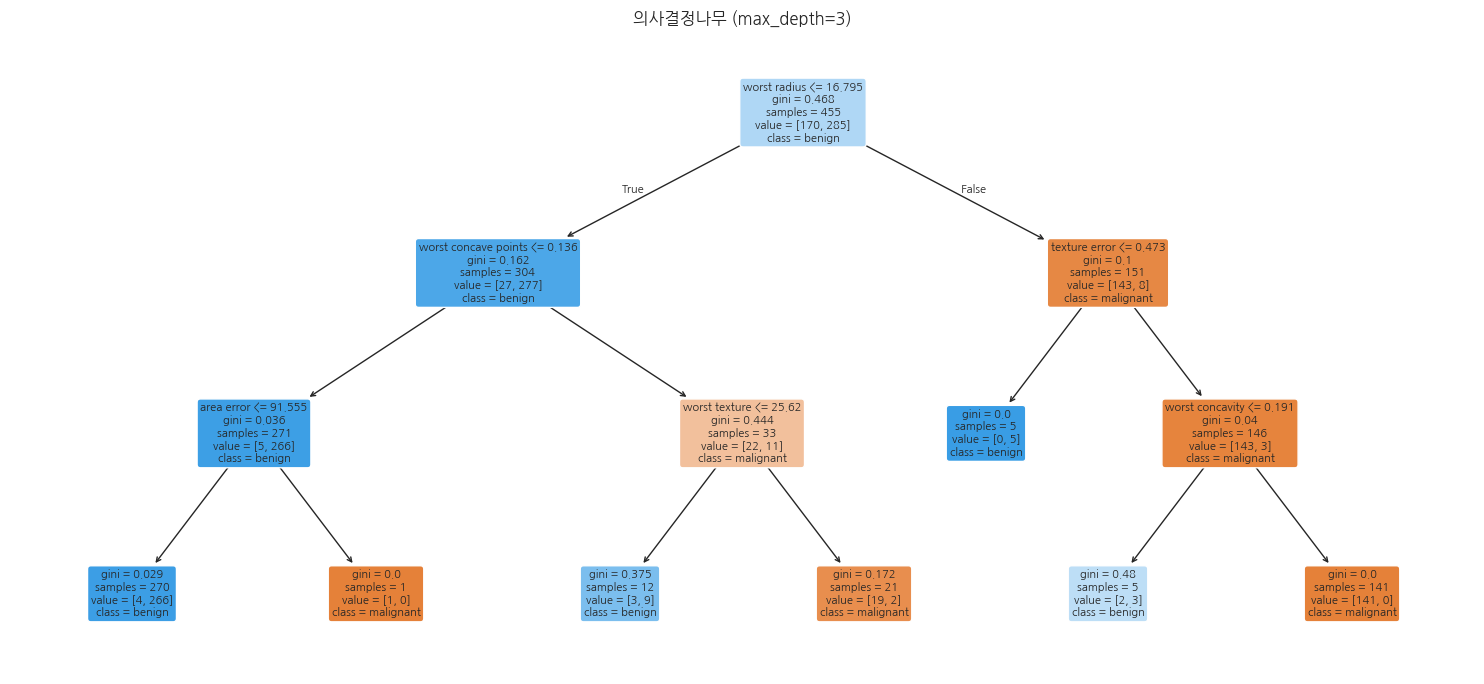

In [4]:
# [C4] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree.fit(Xc_tr, yc_tr)
print(f"테스트 정확도 = {tree.score(Xc_te, yc_te):.3f}")

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree, feature_names=Xc.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title("의사결정나무 (max_depth=3)")
plt.tight_layout(); plt.show()

> 🎯 **[C4] 예상과 맞았나요?** 트리가 첫 질문으로 고른 피처가 보입니다. 트리는 **불순도를 가장 많이 떨어뜨리는 질문**을 스스로 찾았습니다. 깊이 3만으로도 꽤 높은 정확도가 나오는데, 이것이 트리의 매력입니다 — 규칙이 사람에게 읽히면서 성능도 나옵니다.

> **[C4] 읽는 법:** 각 박스의 첫 줄이 **질문(분기 조건)**, `gini`가 그 노드의 불순도, `samples`가 도달한 샘플 수, `value`가 클래스별 개수입니다. 위에서 아래로 질문에 답하며 내려가면 예측이 나옵니다. **사람이 그대로 따라 읽을 수 있죠** — 이것이 트리의 가장 큰 매력입니다.

> 📌 **다른 산업에서는?** 트리의 해석력 덕분에 **금융**(대출 승인 규칙), **헬스케어**(진단 가이드), **제조**(불량 원인 분기)처럼 *"왜 그렇게 판단했는지 설명해야 하는"* 분야에서 특히 사랑받습니다.

### 손으로 따라가는 분할 — "소개팅 데이터"로 직관 잡기

수식이 추상적이면 작은 예로 감을 잡읍시다. 여동생의 소개팅 데이터(8명)에서 "잘생김?"으로 나눴더니 이렇게 됐다고 합시다.

| 그룹 | 소개팅 Yes | 소개팅 No |
|------|-----------|-----------|
| 잘생김 = 예 | 4 | 0 |
| 잘생김 = 아니오 | 0 | 4 |

- 두 그룹 모두 한쪽으로 완벽히 쏠림 → **각 그룹 지니 = 0** (완전 순수!)
- 분할 전(4:4)의 지니 = $1-(0.5^2+0.5^2)=0.5$
- **정보획득 = 0.5 − 0 = 0.5** → 아주 좋은 질문!

반대로 "키 큼?"으로 나눴더니 두 그룹이 여전히 2:2로 섞였다면 정보획득은 0에 가깝습니다. 트리는 이렇게 **여러 질문의 정보획득을 비교해 가장 큰 것을 먼저** 던집니다. 그게 루트 노드가 되고, 그 아래로 같은 일을 재귀적으로 반복합니다.

### 왜 반반(50:50)이 가장 불순한가

지니 불순도를 클래스 비율 $p$에 따라 계산해 보면 이렇습니다.

| 클래스 1의 비율 $p$ | 지니 $1-(p^2+(1-p)^2)$ | 상태 |
| --- | --- | --- |
| 0.0 | **0.000** | 완전히 순수 (전부 클래스 0) |
| 0.25 | 0.375 | 한쪽으로 치우침 |
| **0.50** | **0.500** | **가장 불순** (반반이라 예측 불가) |
| 0.75 | 0.375 | 한쪽으로 치우침 |
| 1.0 | **0.000** | 완전히 순수 (전부 클래스 1) |

**양 끝에서 0이고 가운데에서 최대**인 언덕 모양입니다. 엔트로피도 계수만 다르고 모양은 같습니다.

직관은 이렇습니다 — 노드에 한 클래스만 있으면 "여기 오면 무조건 이 답"이라 확신할 수 있으니 불순도 0입니다. 반반이면 어느 쪽도 못 고르니 불순도가 최대입니다. **트리는 이 값을 가장 많이 떨어뜨리는 질문을 고릅니다.**

지니와 엔트로피가 "반반일 때 최대, 한쪽 100%일 때 0"이라는 걸 곡선으로 확인해 봅시다. 두 곡선의 모양이 거의 같다는 것도 눈으로 보입니다.

> **[C4] 읽는 법:** 가로축은 한 클래스의 비율, 세로축은 불순도입니다. 정확히 반반(0.5)일 때 가장 불순하고, 한쪽으로 완전히 쏠리면(0 또는 1) 불순도가 0이 됩니다. 트리는 이 곡선의 **높은 곳(불순)에서 낮은 곳(순수)으로** 데이터를 밀어내는 질문을 찾는 셈입니다.

### 트리의 결정경계는 "계단" 모양입니다

로지스틱 회귀의 경계는 *직선*이었습니다. 트리는 한 번에 한 피처를 기준으로 자르기 때문에 경계가 **축에 평행한 계단** 모양이 됩니다. 두 피처만 써서 눈으로 봅시다.

▶ 실행: [C5]

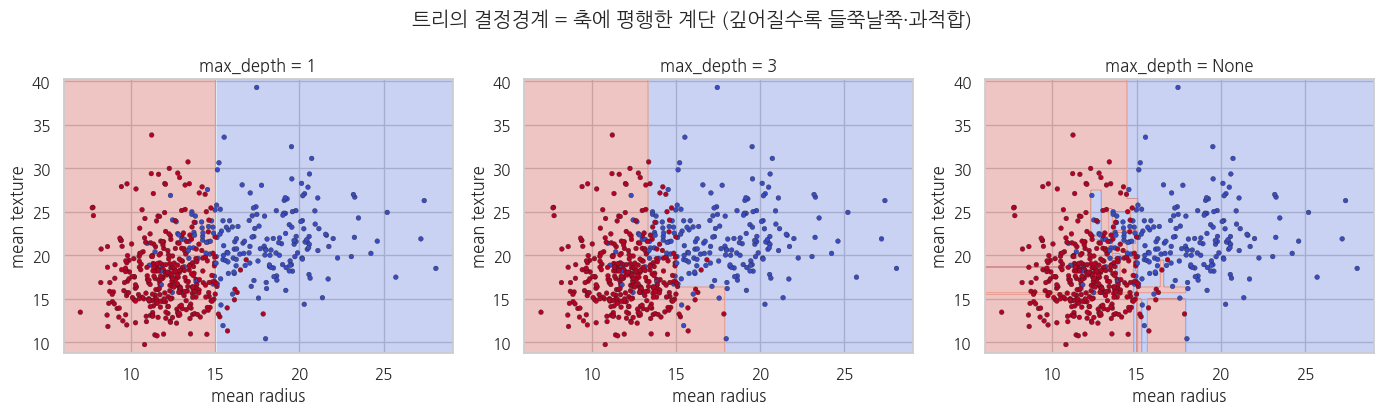

In [5]:
# ─────────────────────────────────────────────
# [C5] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기 단일 트리의 결정경계 (계단 모양) — 깊이별 비교
# ─────────────────────────────────────────────
feats = ["mean radius", "mean texture"]
X2 = Xc[feats].values
import numpy as np
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, d in zip(axes, [1, 3, None]):
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X2, yc)
    zz = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2[:,0], X2[:,1], c=yc, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(f"max_depth = {d}"); ax.set_xlabel(feats[0]); ax.set_ylabel(feats[1])
plt.suptitle("트리의 결정경계 = 축에 평행한 계단 (깊어질수록 들쭉날쭉·과적합)")
plt.tight_layout(); plt.show()

# 분할 횟수가 증가할수록 경계가 더 세밀하고 계단형으로 복잡해질 수 있다.

> **[C5] 읽는 법:** 깊이가 1이면 경계가 단순(선 하나), 깊어질수록 **들쭉날쭉한 계단**이 되어 학습 데이터에 딱 맞춰집니다(과적합). 다음 Part에서 이 들쭉날쭉함을 *여러 나무의 평균*으로 부드럽게 만드는 걸 보게 됩니다.

## ⌨️ 백문이 불여일타! (1)

```
[문제]
1) 분할 기준을 지니 대신 엔트로피로 바꿔(criterion="entropy") 트리를 다시 학습해보세요.
2) 지니 기준 트리와 테스트 정확도를 비교해보세요.
```

지니 테스트 정확도 = 0.939
엔트로피 테스트 정확도 = 0.947


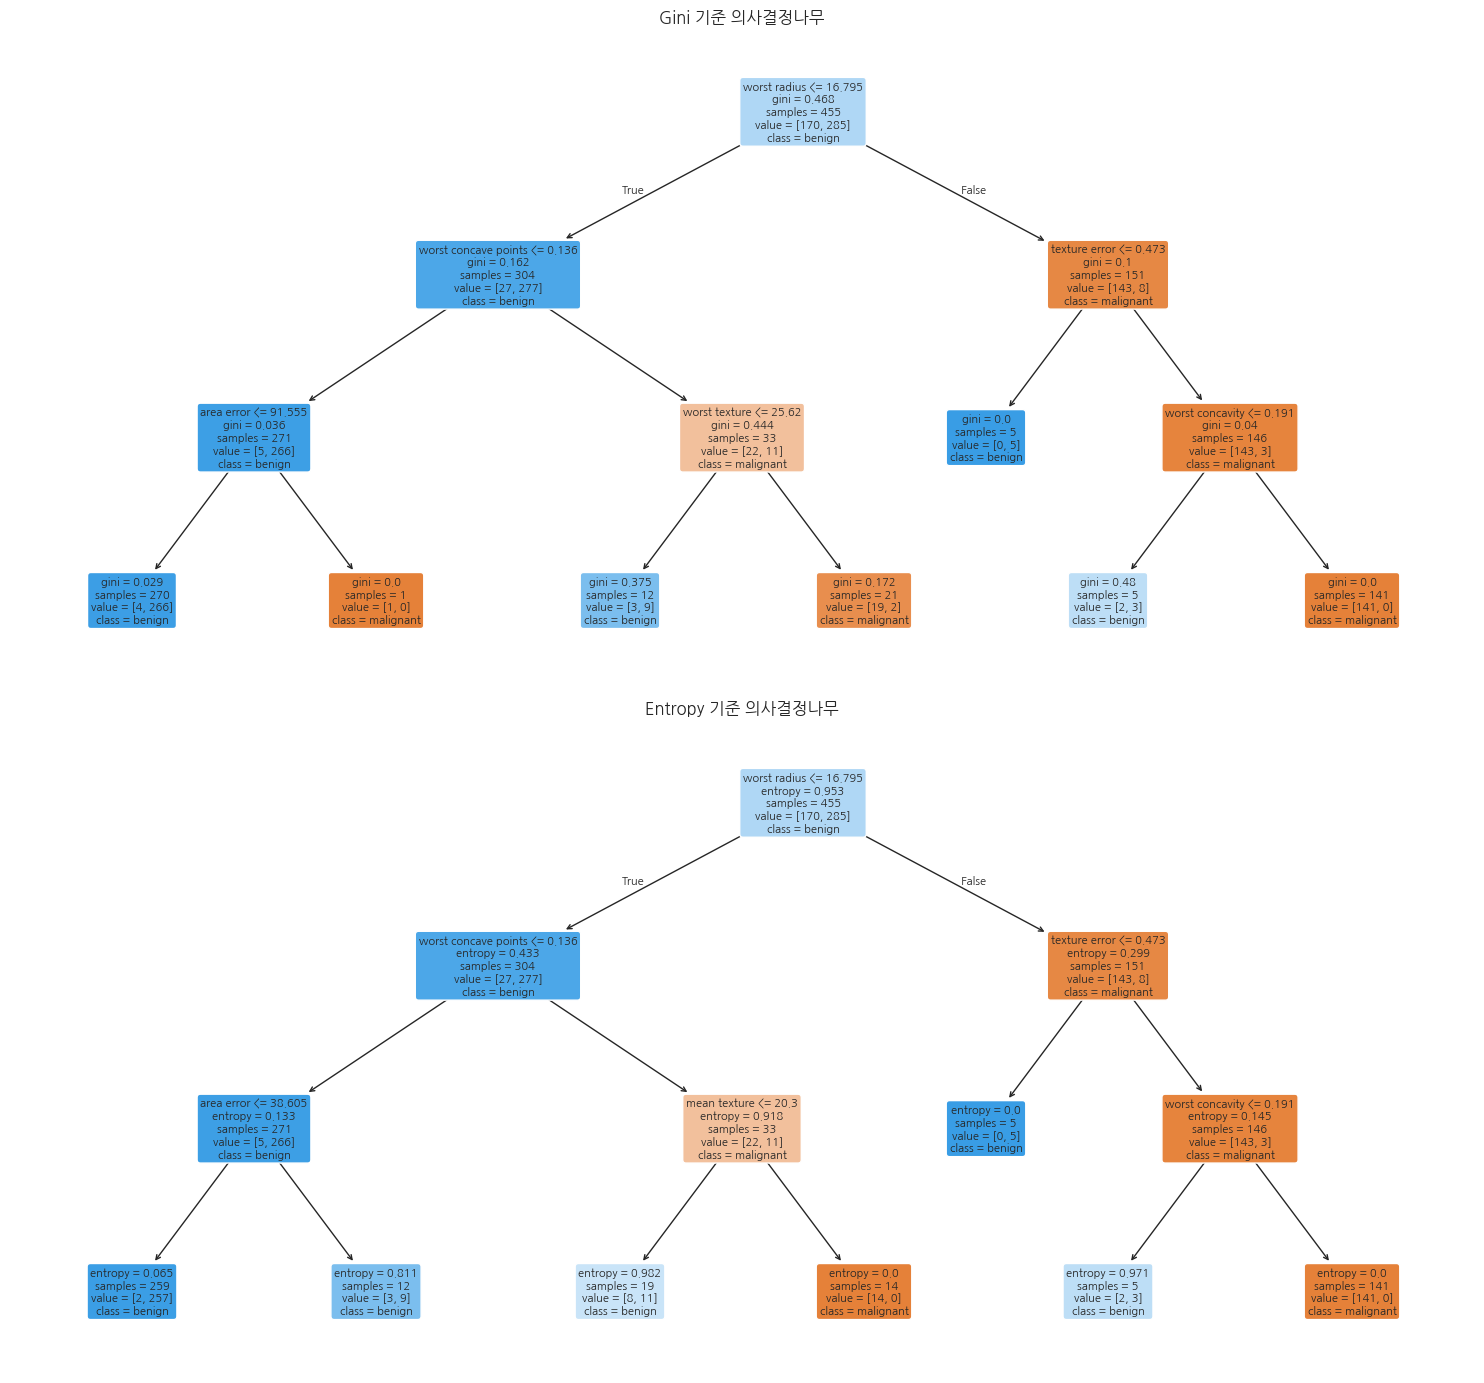

In [6]:
# [C6] ◀ Part 1 · ⌨️ 백문이 불여일타! (1) ⌨️ 백문이 불여일타! (1) — criterion을 entropy로 바꿔 비교

# 여기에 코드를 작성하세요

tree_entropy = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, criterion="entropy")
tree_entropy.fit(Xc_tr, yc_tr)

print(f"지니 테스트 정확도 = {tree.score(Xc_te, yc_te):.3f}")
print(f"엔트로피 테스트 정확도 = {tree_entropy.score(Xc_te, yc_te):.3f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14))

plot_tree(tree, feature_names=Xc.columns, class_names=["malignant", "benign"], filled=True, rounded=True, fontsize=8, ax=ax1)
ax1.set_title("Gini 기준 의사결정나무")

plot_tree(tree_entropy, feature_names=Xc.columns, class_names=["malignant", "benign"], filled=True, rounded=True, fontsize=8, ax=ax2)
ax2.set_title("Entropy 기준 의사결정나무")

plt.tight_layout()
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- [C4]에서 만든 `tree`가 지니 기준 트리입니다. 같은 설정(`max_depth=3`, `random_state=42`)에서 `criterion="entropy"`만 바꾼 트리를 하나 더 만들어보세요.
- 두 트리의 테스트 정확도는 `.score(Xc_te, yc_te)`로 바로 비교할 수 있습니다.

</details>

## 🚦 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. 지니 불순도가 가장 큰 경우는 클래스 비율이 어떨 때인가요?
2. 트리는 매 분기에서 무엇을 최대화하는 질문을 고르나요?
3. 트리의 가장 큰 장점 하나는 무엇인가요?

> 💡 **다음 Part 예고:** 트리는 강력하지만, **끝까지 키우면 데이터를 외워버립니다(과적합).** 한 그루 나무의 약점을 들여다봅시다.

> 📋 **의사결정나무 장단점 한 줄 요약**
> - 👍 **장점:** 사람이 읽을 수 있음(해석력), 전처리(스케일링·결측 더미화) 부담 적음, 비선형·상호작용 자동 포착, 분류·회귀 모두 가능.
> - 👎 **단점:** 깊어지면 과적합, 데이터가 조금 바뀌면 트리가 크게 흔들림(불안정), 축에 평행한 계단 경계라 부드러운 경계엔 약함.
> 이 단점들을 **앙상블이 보완**합니다 — 그래서 실무에서는 단일 트리보다 랜덤포레스트·XGBoost를 훨씬 자주 씁니다.

# Part 2. 트리는 왜 과적합할까 — 가지치기

의사결정나무는 깊이 제한이 없으면 **잎마다 샘플 하나가 남을 때까지** 질문을 계속 던집니다. 그러면 학습 데이터는 100% 맞히지만, 새 데이터에선 무너집니다. 바로 **과적합**입니다.

> ❓ **이 파트에서 답할 질문:** 트리의 과적합을 어떻게 눈으로 보고, 어떻게 막을까?

## 💡 쉽게 말하면 — 너무 꼬치꼬치 캐물으면 외운다

스무고개에서 질문을 *끝없이* 던지면, 결국 "이 사람은 키 173.2cm에 화요일 출생이며 …"처럼 **그 사람 한 명에게만 맞는 규칙**이 됩니다. 새 사람에겐 쓸모없습니다. 그래서 트리의 깊이를 적당히 **제한(가지치기, pruning)** 합니다.

- `max_depth` : 최대 깊이
- `min_samples_leaf` : 잎이 가져야 할 최소 샘플 수
- `max_leaf_nodes` : 최대 잎 개수

이것들이 트리의 **하이퍼파라미터**입니다(사람이 정하는 값).

## 🔍 자세히 알아보기 — 왜 앙상블이 답일까 (편향과 분산)

머신러닝 오차는 크게 두 종류로 쪼갤 수 있습니다(이후 더 깊이 다룹니다).

- **편향(Bias):** 모델이 너무 단순해서 진짜 패턴을 못 잡는 오차 (과소적합)
- **분산(Variance):** 데이터가 조금만 바뀌어도 예측이 출렁이는 오차 (과적합)

깊은 단일 트리는 **분산이 큰** 대표 선수입니다(데이터에 민감, 불안정). 그런데 통계에 이런 사실이 있습니다 — **독립적인 여러 추정치를 평균하면 분산이 줄어든다.** 그래서:

- **배깅/랜덤포레스트** = 분산이 큰 깊은 나무들을 **평균** → *분산을 깎는다*
- **부스팅** = 약한(편향 큰) 얕은 나무를 **순차로 보강** → *편향을 깎는다*

즉 앙상블의 두 전략은 각각 **분산 문제**와 **편향 문제**를 공략하는 서로 다른 처방입니다. 같은 "약한 학습기 모으기"인데 노리는 게 다른 겁니다.

## 📊 데이터로 확인해 봅시다 — 깊이를 키우면 무엇이 벌어지나

말로 "과적합한다"고 하는 것보다 직접 재보는 편이 빠릅니다. 트리의 깊이를 1부터 키우며 학습 점수와 테스트 점수를 나란히 봅니다.

> 🤔 **예상해 볼까요?** 트리의 깊이를 계속 키우면 **학습 정확도**는 어디까지 갈까요? 그리고 그때 **테스트 정확도**는 함께 올라갈까요, 어느 지점에서 꺾일까요?

▶ 실행: [C7]

학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ 3


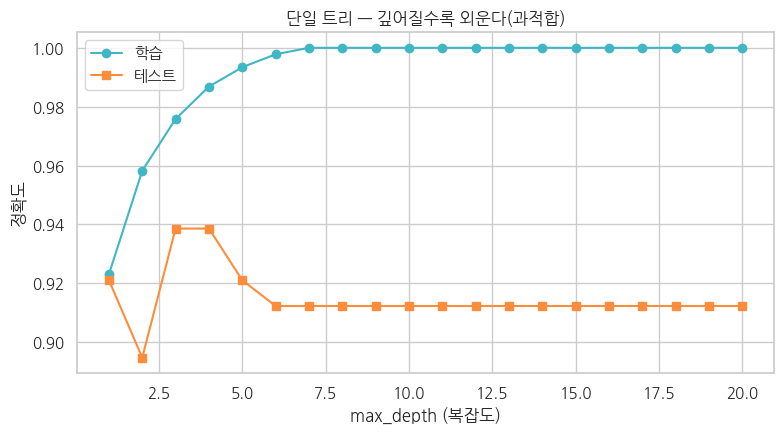

In [7]:
# ─────────────────────────────────────────────
# [C7] ◀ Part 2 · 📊 데이터로 확인해 봅시다 — 깊이를 키우면 무엇이 벌어지나 깊이를 키울수록 학습↑·테스트는 정체 → 과적합
# ─────────────────────────────────────────────
depths = range(1, 21)
tr, te = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    tr.append(m.score(Xc_tr, yc_tr)); te.append(m.score(Xc_te, yc_te))

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
plt.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("단일 트리 — 깊어질수록 외운다(과적합)")
plt.legend(); plt.tight_layout(); plt.show()

best = list(depths)[int(np.argmax(te))]
print(f"학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ {best}")

> 🎯 **[C7] 예상과 맞았나요?** 학습 점수는 **1.000까지** 올라가는데 테스트 점수는 어느 지점에서 꺾여 정체합니다. 깊이를 더 키워도 테스트는 나아지지 않고 **격차만 벌어집니다.** 이것이 한 그루 나무의 약점이고, 다음 Part에서 여러 그루를 모으는 이유입니다.

> **[C7] 읽는 법:** 학습 정확도(파랑)는 깊이가 커질수록 **1.0까지** 오르지만, 테스트(주황)는 어느 지점에서 멈추거나 떨어집니다. 이 격차가 **단일 트리의 약점** — 불안정하고 과적합하기 쉽습니다.

> 💡 **핵심:** 그래서 **얕은 트리는 약하고(과소적합), 깊은 트리는 외웁니다(과적합).** 이 딜레마를 푸는 우아한 방법이 다음 Part의 **앙상블**입니다 — "약한 나무 여러 그루를 모으자!"

> 💡 **과적합 vs 과소적합, 다시 한 번:** 과적합은 *벼락치기로 기출문제만 통째 외운 학생*입니다 — 본 문제(학습)는 100점인데 새 문제(테스트)는 무너집니다. 과소적합은 *공부를 너무 안 한 학생* — 본 문제조차 못 풉니다. 우리가 원하는 건 *개념을 이해한 학생* — 처음 보는 문제도 푸는 **일반화**입니다. 단일 트리는 깊어지면 전자(벼락치기)가 되기 쉬워서, 앙상블로 "여러 학생의 평균"을 내 안정시키는 거입니다.

> 📌 **다른 산업에서는?** 단일 트리는 **규칙이 명확해야 하는** 곳(은행 대출 심사 가이드, 의료 분류 기준)에서 그 자체로 쓰이지만, 과적합·불안정 때문에 *예측 정확도*가 중요한 실무에서는 대부분 **앙상블(랜덤포레스트·XGBoost)** 로 넘어갑니다. "설명용 트리 1그루 + 예측용 앙상블"을 함께 쓰기도 해요.

## ⌨️ 백문이 불여일타! (2)

```
[문제]
1) min_samples_leaf(잎 최소 샘플 수)를 1 → 5 → 20으로 키우며, 깊이 제한 없이(max_depth=None) 트리를 학습해보세요.
2) 각 설정의 학습·테스트 정확도를 출력해, 잎 최소 샘플을 키울수록 학습-테스트 격차가 어떻게 변하는지 관찰해보세요.
```

min_samples_leaf=1: max_depth=1일 때 학습 0.923 → 20일 때 1.000로 변화했습니다. 테스트 최고는 0.939 (max_depth=3)
min_samples_leaf=5: max_depth=1일 때 학습 0.923 → 20일 때 0.976로 변화했습니다. 테스트 최고는 0.939 (max_depth=3)
min_samples_leaf=20: max_depth=1일 때 학습 0.923 → 20일 때 0.947로 변화했습니다. 테스트 최고는 0.921 (max_depth=1)


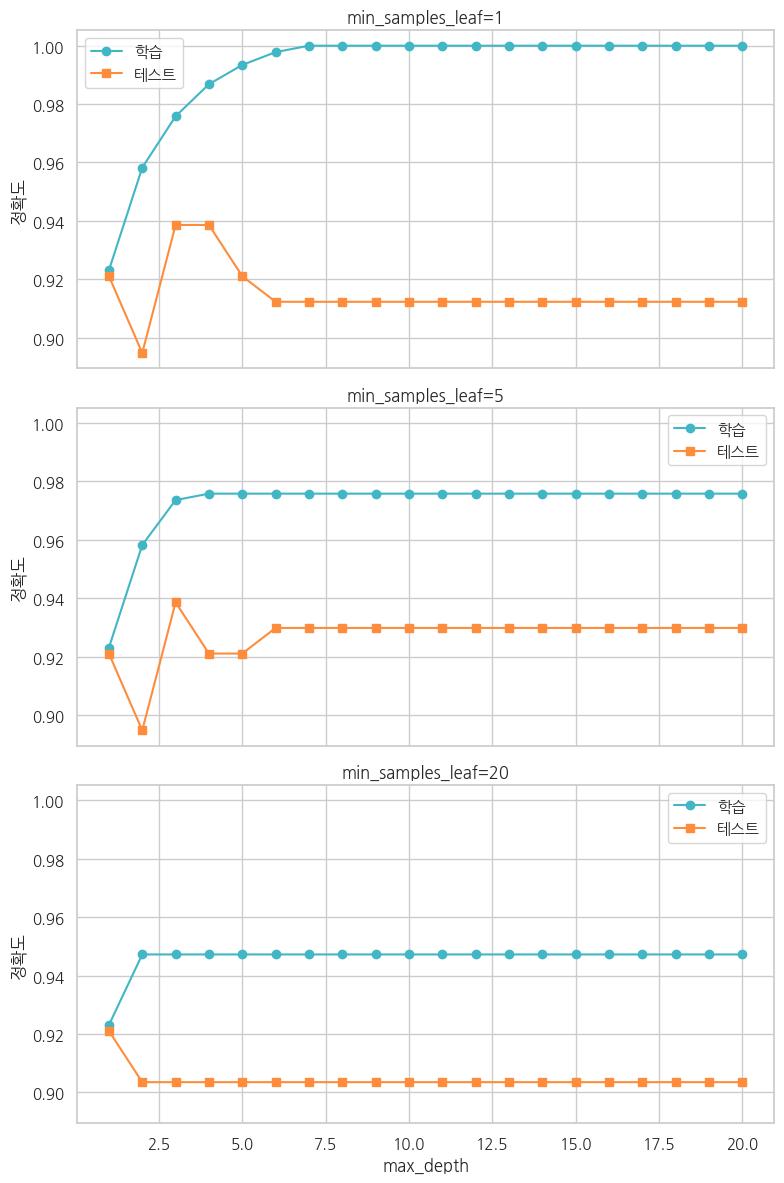

In [8]:
# [C8] ◀ Part 2 · ⌨️ 백문이 불여일타! (2) ⌨️ 백문이 불여일타! (2) — min_samples_leaf 효과 실험

depths = range(1, 21)
leaf_list = [1, 5, 20]

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True, sharey=True)

for i, leaf in enumerate(leaf_list):
    tr, te = [], []
    for d in depths:
        m = DecisionTreeClassifier(max_depth=d, min_samples_leaf=leaf, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
        tr.append(m.score(Xc_tr, yc_tr)); te.append(m.score(Xc_te, yc_te))

    axes[i].plot(depths, tr, "o-", label="학습", color="#41b6c4")
    axes[i].plot(depths, te, "s-", label="테스트", color="#fd8d3c")
    axes[i].set_title(f"min_samples_leaf={leaf}")
    axes[i].set_ylabel("정확도")
    axes[i].legend()

    best = list(depths)[int(np.argmax(te))]
    print(f"min_samples_leaf={leaf}: max_depth=1일 때 학습 {tr[0]:.3f} → 20일 때 {tr[-1]:.3f}로 변화했습니다. 테스트 최고는 {max(te):.3f} (max_depth={best})")

axes[-1].set_xlabel("max_depth")
plt.tight_layout(); plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- `DecisionTreeClassifier(min_samples_leaf=..., random_state=42)`처럼 인자 하나만 바꾸면 됩니다. `max_depth`를 지정하지 않으면 기본값이 `None`(제한 없음)입니다.
- 1, 5, 20 세 값을 `for` 반복문으로 돌리면 코드가 짧아집니다.
- 과적합 여부는 [C7]에서 본 것처럼 학습 정확도와 테스트 정확도의 격차로 판단합니다 — 두 점수를 나란히 출력해보세요.

</details>

## 🚦 짚고 넘어가기

1. 깊이 제한이 없는 트리가 과적합하는 이유를 한 문장으로 말해보세요.
2. 가지치기 하이퍼파라미터를 두 개 이상 들어보세요.
3. 학습 1.0 / 테스트 0.90이면 무엇을 의심하나요?

> 💡 **다음 Part 예고:** 한 그루가 불안정하다면, **여러 그루를 길러 투표**시키면 어떨까요? 첫 번째 앙상블 — 랜덤포레스트로 갑니다.

# Part 3. 숲을 이루다 — 배깅과 랜덤포레스트

**앙상블(Ensemble)** = 약한 모형 여러 개를 모아 강한 모형을 만드는 것. 그 첫 전략이 **배깅(Bagging)** 이고, 의사결정나무로 배깅하면 **랜덤포레스트(Random Forest)** 가 됩니다.

> ❓ **이 파트에서 답할 질문:** 나무를 여러 그루 모으면 *왜* 더 정확하고 안정적이 될까?

## 💡 쉽게 말하면 — 여러 전문가의 투표

한 사람의 판단은 틀릴 수 있지만, **서로 다른 자료를 본 여러 전문가가 투표**하면 평균적으로 더 정확합니다. 배깅이 정확히 이 일을 합니다.

**배깅 = Bootstrap + Aggregating**
1. **부트스트랩:** 원 데이터에서 **복원추출**로 표본을 여러 벌 만든다(같은 데이터가 여러 번 뽑힐 수 있음).
2. 각 표본으로 **독립적인 트리**를 학습.
3. **집계:** 분류는 다수결 투표, 회귀는 평균.

**랜덤포레스트**는 여기에 한 가지를 더합니다 — 각 분기에서 **피처도 무작위 일부만** 후보로 씁니다(`max_features`). 그래야 나무들이 서로 더 달라지고, 투표 효과가 커져요.

![배깅 도해 — 원본 데이터에서 복원추출로 여러 표본을 만들어 각각 독립적인 분류기를 학습시키고, 그 결과를 집계해 하나의 앙상블 분류기를 만든다](https://upload.wikimedia.org/wikipedia/commons/thumb/c/c8/Ensemble_Bagging.svg/960px-Ensemble_Bagging.svg.png)

*(출처: [Ensemble Bagging](https://commons.wikimedia.org/wiki/File:Ensemble_Bagging.svg) — Sirakorn, CC BY-SA 4.0)*

> **[C8] 읽는 법:** 위에서 아래로 읽습니다. 원본 데이터(Original Data)에서 **복원추출로 여러 벌**을 만들고(Bootstrapping), 각 벌로 **독립적인** 분류기를 학습시킨 뒤, 결과를 **집계**(Aggregating)해 하나의 앙상블을 만듭니다. 세 갈래가 **나란히 그려진 것**이 핵심입니다 — 서로를 기다리지 않고 동시에 학습할 수 있습니다.

### "랜덤"이 두 번 들어갑니다

랜덤포레스트의 "랜덤"은 사실 **두 가지 무작위성**을 뜻합니다.

1. **데이터(행) 무작위:** 각 나무는 부트스트랩으로 뽑은 *서로 다른 표본*으로 학습합니다.
2. **피처(열) 무작위:** 각 분기에서 전체 피처가 아니라 *무작위로 고른 일부*만 후보로 봅니다(`max_features`).

왜 두 번이나 흔들까요? **나무들이 서로 너무 닮으면 평균을 내도 분산이 안 줄기 때문**입니다. 예를 들어 아주 강한 피처 하나가 있으면 모든 나무가 그것부터 분기해 거의 똑같아집니다. 피처까지 무작위로 제한하면 나무마다 *다른 관점*을 갖게 되어, 투표로 모았을 때 효과가 커집니다. "다양성이 곧 힘"이라는 앙상블의 철학이 여기 담겨 있습니다.

### 부트스트랩, 직접 해보기

배깅의 출발점인 **복원추출(Bootstrap)** 을 눈으로 봅시다. 10개에서 10개를 *복원추출*하면 어떤 건 여러 번, 어떤 건 한 번도 안 뽑힙니다. 평균적으로 약 **63%만 뽑히고 37%는 빠지는데**, 이 "빠진 데이터"가 공짜 검증용(OOB)이 되기도 합니다.

## 🔍 자세히 알아보기 — 왜 좋아지나 (분산을 줄이는 평균화)

배깅의 통계적 핵심은 **"여러 독립 모형의 예측을 평균하면 분산이 준다"** 입니다. 개별 트리는 데이터에 과적합(분산↑)하지만, 서로 다른 트리들의 결과를 **평균/투표**하면 그 출렁임이 상쇄됩니다.

나무를 늘릴수록(`n_estimators`↑) 보통 테스트 성능이 안정화됩니다(단, 무한정 좋아지진 않음 — 비용만 늘 수 있음).

## 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트

배깅의 두 단계를 코드로 확인합니다. 먼저 부트스트랩이 실제로 무엇을 하는지 한 번 뽑아 보고, 그다음 단일 트리와 랜덤포레스트를 같은 데이터로 비교합니다.

> 🤔 **예상해 볼까요?** 복원추출로 원 데이터와 같은 크기의 표본을 뽑으면, 원 데이터의 몇 %가 **한 번도 안 뽑힐** 것 같습니까? 10% 정도일까요, 30%를 넘을까요?

▶ 실행: [C9]

In [9]:
# [C9] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트 부트스트랩 한 번 — 중복과 누락 관찰
import numpy as np
np.random.seed(1)
original = np.arange(10)
boot = np.random.choice(original, size=10, replace=True)  # 복원추출
print("원본     :", original)
print("부트스트랩:", np.sort(boot))
print("뽑힌 고유값 개수:", len(set(boot)), "/ 10")
print(f"이론상 평균 포함 비율 ≈ {1-(1-1/len(original))**len(original):.0%}")

원본     : [0 1 2 3 4 5 6 7 8 9]
부트스트랩: [0 0 1 5 5 6 7 8 9 9]
뽑힌 고유값 개수: 7 / 10
이론상 평균 포함 비율 ≈ 65%


> 🎯 **[C9] 예상과 맞았나요?** 복원추출을 한 번 하면 원 데이터의 **약 37%가 한 번도 안 뽑힙니다.** 생각보다 큰 비율입니다. 그리고 이 '안 뽑힌 표본'이 공짜 검증셋(OOB)이 됩니다 — 버려지는 것이 아니라 쓰임이 있습니다.

▶ 실행: [C10]

In [10]:
# ─────────────────────────────────────────────
# [C10] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트 단일 트리 vs 랜덤포레스트 — 직접 비교
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

single = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(Xc_tr, yc_tr)

print("단일 트리   : 학습 {:.3f} / 테스트 {:.3f}".format(single.score(Xc_tr,yc_tr), single.score(Xc_te,yc_te)))
print("랜덤포레스트 : 학습 {:.3f} / 테스트 {:.3f}".format(rf.score(Xc_tr,yc_tr), rf.score(Xc_te,yc_te)))
print("\n→ 둘 다 학습은 1.0에 가깝지만, 테스트 정확도와 '안정성'이 랜덤포레스트가 낫습니다.")

단일 트리   : 학습 1.000 / 테스트 0.912
랜덤포레스트 : 학습 1.000 / 테스트 0.947

→ 둘 다 학습은 1.0에 가깝지만, 테스트 정확도와 '안정성'이 랜덤포레스트가 낫습니다.


나무를 늘릴수록 성능이 어떻게 움직이는지 직접 확인해 봅니다.

▶ 실행: [C11]

→ 나무가 적을 땐 출렁이다가, 늘릴수록 성능이 안정됩니다.


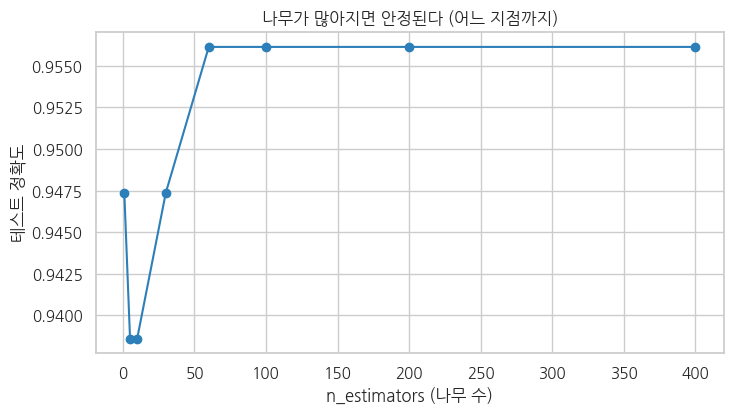

In [11]:
# ─────────────────────────────────────────────
# [C11] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트 나무 수(n_estimators)에 따른 테스트 정확도
# ─────────────────────────────────────────────
ns = [1, 5, 10, 30, 60, 100, 200, 400]
scores = [RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
          .fit(Xc_tr, yc_tr).score(Xc_te, yc_te) for n in ns]

plt.figure(figsize=(7.5, 4.3))
plt.plot(ns, scores, "o-", color="#2c7fb8")
plt.xlabel("n_estimators (나무 수)"); plt.ylabel("테스트 정확도")
plt.title("나무가 많아지면 안정된다 (어느 지점까지)")
plt.tight_layout(); plt.show()
print("→ 나무가 적을 땐 출렁이다가, 늘릴수록 성능이 안정됩니다.")

### 공짜 검증 — OOB(Out-of-Bag)

부트스트랩에서 평균 37%의 데이터는 **한 번도 안 뽑힙니다**(Part 3의 부트스트랩 실험에서 봤습니다). 각 나무 입장에서 이 "안 뽑힌 데이터"는 *처음 보는 데이터*나 마찬가지입니다. 그래서 랜덤포레스트는 이 OOB 샘플로 **별도 테스트셋 없이도** 성능을 추정할 수 있습니다(`oob_score=True`). 데이터가 아까울 때 유용한 보너스입니다.

### 랜덤포레스트 핵심 하이퍼파라미터 정리

| 하이퍼파라미터 | 의미 | 크게 하면 |
|----------------|------|-----------|
| `n_estimators` | 나무 수 | 안정↑·느림↑ (과적합엔 둔감) |
| `max_depth` | 나무 깊이 | 표현력↑·과적합 위험↑ |
| `max_features` | 분기 후보 피처 수 | 작을수록 나무 다양성↑(랜덤성↑) |
| `min_samples_leaf` | 잎 최소 샘플 | 클수록 단순·과적합↓ |

> 💡 랜덤포레스트는 **기본값으로도 잘 나오는** 편이라, 튜닝 전에 베이스라인으로 먼저 돌려보길 권합니다.

> 💡 **현업 팁 — 왜 랜덤포레스트가 "첫 선택"인가:** (1) 기본값으로도 성능이 잘 나오고, (2) 과적합에 강건하며, (3) 스케일링이 거의 필요 없고, (4) 피처 중요도를 공짜로 주며, (5) 병렬로 빨라서, 새 데이터를 받으면 *일단 RF부터 돌려 베이스라인을 잡는* 경우가 많습니다. 거기서 더 짜내야 할 때 XGBoost로 넘어가 튜닝하는 흐름이 정석입니다.

> 📌 **다른 산업에서는?** 랜덤포레스트는 **이커머스** 이탈 예측, **금융** 신용평가, **제조** 불량 분류 등 정형 데이터에서 *가장 먼저 시도하는 안전한 강모델*입니다. 튜닝을 거의 안 해도 잘 나와 베이스라인으로 으뜸입니다.

## ⌨️ 백문이 불여일타! (3)

```
[문제]
1) 랜덤포레스트는 회귀에도 됩니다 — RandomForestRegressor로 당뇨 진행도(앞서 배운 회귀 문제)를 예측해보세요.
2) 단일 트리 회귀(DecisionTreeRegressor)와 테스트 R²를 비교해보세요.
```

In [12]:
# [C12] ◀ Part 3 · ⌨️ 백문이 불여일타! (3) ⌨️ 백문이 불여일타! (3) — RandomForestRegressor로 회귀 비교

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

Xr, yr = load_diabetes(as_frame=True, return_X_y=True)

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)
tree_r = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_r.fit(Xr_tr, yr_tr)

rf_r = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_r.fit(Xr_tr, yr_tr)

print(f"단일 트리 학습 R² = {tree_r.score(Xr_tr, yr_tr):.3f}")
print(f"단일 트리 테스트 R² = {tree_r.score(Xr_te, yr_te):.3f}")
print(f"랜덤포레스트 학습 R² = {rf_r.score(Xr_tr, yr_tr):.3f}")
print(f"랜덤포레스트 테스트 R² = {rf_r.score(Xr_te, yr_te):.3f}")

단일 트리 학습 R² = 1.000
단일 트리 테스트 R² = 0.061
랜덤포레스트 학습 R² = 0.924
랜덤포레스트 테스트 R² = 0.434


<details>
<summary>(클릭) 💡 힌트</summary>

- 데이터는 `load_diabetes(as_frame=True)`로 불러와 `train_test_split`으로 나눕니다 — 분류에서 쓰던 것과 같은 패턴입니다.
- `DecisionTreeRegressor`는 `sklearn.tree`, `RandomForestRegressor`는 `sklearn.ensemble`에서 가져옵니다. 사용법은 분류기와 똑같이 `fit` → `score`입니다.
- 회귀 모델의 `.score()`는 정확도가 아니라 R²를 돌려줍니다.

</details>

## 🚦 짚고 넘어가기

1. 배깅의 두 단계(Bootstrap, Aggregating)를 설명해보세요.
2. 랜덤포레스트가 단순 배깅과 다른 점(랜덤성 하나)은 무엇인가요?
3. 배깅은 주로 편향과 분산 중 무엇을 줄이나요?

> 💡 **다음 Part 예고:** 배깅은 나무들을 *독립적으로* 길렀습니다. 그런데 **앞 모델의 실수를 다음 모델이 고쳐준다면** 어떨까요? 또 다른 앙상블 전략 — 부스팅입니다.

# Part 4. 오차를 보정하며 배운다 — 부스팅(Boosting)

배깅이 "독립 전문가들의 투표(병렬)"라면, **부스팅(Boosting)** 은 "**앞 사람의 실수를 다음 사람이 고치는 릴레이(순차)**"입니다. 약한 모형을 *순서대로* 쌓으며 오차를 줄여 갑니다.

> ❓ **이 파트에서 답할 질문:** "오차를 순차적으로 보정한다"는 게 구체적으로 무슨 뜻일까?

## 💡 AdaBoost — 틀린 것을 더 강조한다

가장 단순한 부스팅. 깊이 1짜리 트리(**Stump**)를 순차로 만들며, **틀린 샘플의 가중치를 키워** 다음 모형이 그걸 더 신경 쓰게 합니다.

1. 모든 샘플 가중치 동일하게 시작.
2. Stump 학습 → 오차 계산 → 그 Stump의 **중요도(Amount of Say)** 결정(잘 맞히면 발언권↑).
3. **틀린 샘플 가중치↑** → 다음 표본에 더 자주 등장.
4. 예측: 모든 Stump를 **중요도로 가중 투표**.

## 🔍 자세히 알아보기 — 부스팅 3대장, 무엇이 다른가

| | **AdaBoost** | **Gradient Boosting** | **XGBoost** |
|---|---|---|---|
| 보정 방식 | 틀린 샘플 **가중치↑** | **잔차**를 학습 | 잔차 학습 + **정규화** |
| 약학습기 | Stump(depth=1) | 얕은 트리 | 얕은 트리 |
| 과적합 제어 | 약함 | 학습률 | 학습률 + **L1/L2/gamma** |
| 속도 | 보통 | 보통 | **빠름**(병렬·캐시) |
| 결측 처리 | 직접 | 직접 | **자동** |
| 위치 | 부스팅의 시초 | 표준 | 현대 챔피언 |

> 💡 셋은 "오차를 순차 보정한다"는 **같은 뿌리**입니다. AdaBoost로 직관을 잡고 → GBM으로 일반화(잔차+경사하강) → XGBoost로 실전(정규화+속도)이라는 발전 순서로 이해하면 깔끔합니다.

> 📌 **왜 부스팅이 대회를 휩쓸까?** 캐글 같은 데이터 대회의 정형 데이터 부문에서는 **XGBoost·LightGBM 계열이 우승을 독식**하다시피 합니다. 이유는 (1) 잔차를 끈질기게 줄여 *편향을 끝까지 낮추고*, (2) 정규화로 과적합을 통제하며, (3) 빠르고 결측·이상치에 강하기 때문입니다. 그래서 실무에서도 "정형 데이터로 최고 성능이 필요하면 일단 XGBoost"가 정석이 됐습니다. 다만 그만큼 **튜닝**의 손이 가고, **해석**의 숙제가 남습니다.

## 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로

AdaBoost → Gradient Boosting → XGBoost를 같은 데이터에 학습시켜 봅니다. 세 모델이 "순차 보정"이라는 같은 아이디어를 어떻게 다르게 구현했는지 결과로 확인합니다.

> 🤔 **예상해 볼까요?** 앞서 랜덤포레스트가 단일 트리를 크게 앞섰습니다. 부스팅은 랜덤포레스트보다 **또 한 번 나아질까요?** 아니면 비슷한 수준에서 멈출까요?

▶ 실행: [C13]

In [13]:
# ─────────────────────────────────────────────
# [C13] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 AdaBoost — Stump를 순차로 쌓기
# ─────────────────────────────────────────────
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
print(f"AdaBoost 테스트 정확도 = {ada.score(Xc_te, yc_te):.3f}")

AdaBoost 테스트 정확도 = 0.965


> 🎯 **[C13] 예상과 맞았나요?** 부스팅이 랜덤포레스트를 또 한 번 앞섭니다. 배깅은 *분산*을 줄이고 부스팅은 *편향*까지 줄이기 때문입니다. 다만 부스팅은 **학습률·나무 수에 민감**해서 설정을 잘못 잡으면 오히려 나빠집니다 — 공짜가 아닙니다.

> 💡 **AdaBoost 중요도, 손으로 한 번:** 8명 데이터에서 한 Stump가 1명만 틀렸다면 Error = 1/8. 그 Stump의 중요도(Amount of Say)는 $\frac{1}{2}\log\frac{1-1/8}{1/8} \approx 0.97$ 로 꽤 높습니다(잘 맞혔으니 발언권↑). 반대로 절반을 틀리면(Error=0.5) 중요도는 0 — "동전 던지기 수준이라 발언권 없음". 이렇게 **잘 맞힌 Stump의 표를 더 세게** 쳐주고, **틀린 샘플은 다음 라운드에서 더 자주 등장**시키는 게 AdaBoost의 전부입니다.

> 📌 **배깅 vs 부스팅, 실무 감각:** 배깅(RF)은 **병렬**이라 빠르고 안정적이며 과적합에 강해 *먼저 써보는 안전한 선택*입니다. 부스팅(XGBoost)은 **순차**라 보통 *정확도 1등*이지만, 학습률·트리 수·깊이를 잘못 주면 과적합하니 **튜닝이 필요**합니다. "안정의 RF, 성능의 XGBoost"로 기억하세요.

### Gradient Boosting (GBM) — 잔차를 학습한다

AdaBoost를 일반화한 것이 **GBM**입니다. 핵심 아이디어가 우아합니다.

1. 첫 예측 = 타겟의 **평균**.
2. **잔차(= 실제 − 현재 예측)** 를 계산하고, **그 잔차를 예측하는 트리**를 새로 학습.
3. 예측 갱신: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$  — $\eta$=**학습률**(조금씩 보정), $h_m$=잔차 트리.
4. 반복 → 잔차가 점점 줄며 정밀해짐.

> 💡 **왜 "Gradient"인가:** 손실을 $L=\frac{1}{2}\sum(y-p)^2$로 두면 미분이 $-(y-p)=$ **−잔차**. 즉 *잔차를 따라가는 것 = 경사하강(Gradient Descent)으로 손실을 줄이는 것*입니다. (앞서 배운 "오차를 줄인다"가 여기서 수식으로 이어져요.)

부스팅의 구조를 그림으로 보면 배깅과의 차이가 분명해집니다.

![부스팅 도해 — 원본 데이터로 첫 분류기를 학습하고, 틀린 표본에 가중치를 높여 만든 데이터로 다음 분류기를 학습하는 과정을 순차로 반복한다](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/Ensemble_Boosting.svg/960px-Ensemble_Boosting.svg.png)

*(출처: [Ensemble Boosting](https://commons.wikimedia.org/wiki/File:Ensemble_Boosting.svg) — Sirakorn, CC BY-SA 4.0)*

> **[C13] 읽는 법:** 왼쪽에서 오른쪽으로 **순차**입니다. 첫 분류기가 맞힌 것(초록 ✓)과 틀린 것(빨간 ✗)을 가려낸 뒤, **틀린 표본의 가중치를 높여** 다음 데이터(Weighted data)를 만듭니다. 다음 분류기는 그 어려운 표본에 집중합니다. Part 3의 배깅 그림과 나란히 놓고 보세요 — 배깅은 **동시에 여러 개**, 부스팅은 **하나씩 이어서**입니다.

**학습 절차를 다시 또박또박 정리하면:**

1. **초기 예측 = 타겟의 평균.** (회귀의 "엉망진창 평균선"에서 출발하는 것과 같은 느낌)
2. **잔차 계산** = 실제값 − 현재 예측. (지금 얼마나, 어느 방향으로 틀렸나)
3. **잔차를 타겟으로 트리 학습** → 그 트리가 "어디서 얼마나 틀렸는지"를 예측.
4. **예측 갱신** = 현재 예측 + (학습률 × 잔차 트리의 예측). 학습률(보통 0.05~0.1)을 곱해 **조금씩만** 보정 → 한 번에 확 고치면 과적합하니까.
5. 2~4를 트리 개수만큼 반복.

**예측할 때**도 같은 구조입니다: 초기 평균에서 시작해, 각 트리가 예측한 잔차에 학습률을 곱해 차곡차곡 더하면 최종 예측이 나옵니다. "여러 약한 보정의 합"인 셈입니다.

> 💡 **AdaBoost와의 차이:** AdaBoost는 *틀린 샘플의 가중치*를 키워 다음 모형을 만들고, GBM은 *잔차 자체*를 다음 트리가 학습합니다. GBM이 더 일반적이고 강력해, 오늘날 부스팅의 주류는 GBM 계열(XGBoost·LightGBM·CatBoost)입니다.

### 잔차를 따라가며 맞춰지는 과정 — 눈으로 보기

GBM이 "잔차를 예측하는 트리를 더해 간다"는 말을 1차원 예시로 봅시다. 트리를 1개·5개·50개 더했을 때 예측 곡선이 어떻게 실제에 가까워지는지 관찰하세요.

> **[C13] 읽는 법:** 트리 1개(주황 연함)는 거칠지만, 50개(파랑)는 데이터의 곡선을 잘 따라갑니다. 각 트리가 **앞 단계의 잔차(남은 오차)** 를 조금씩 메우기 때문입니다. 단, 너무 많이/너무 큰 학습률로 더하면 잡음까지 따라가 **과적합**합니다 — 그래서 학습률과 트리 수의 균형이 중요합니다.

▶ 실행: [C14]

Gradient Boosting 테스트 정확도 = 0.956


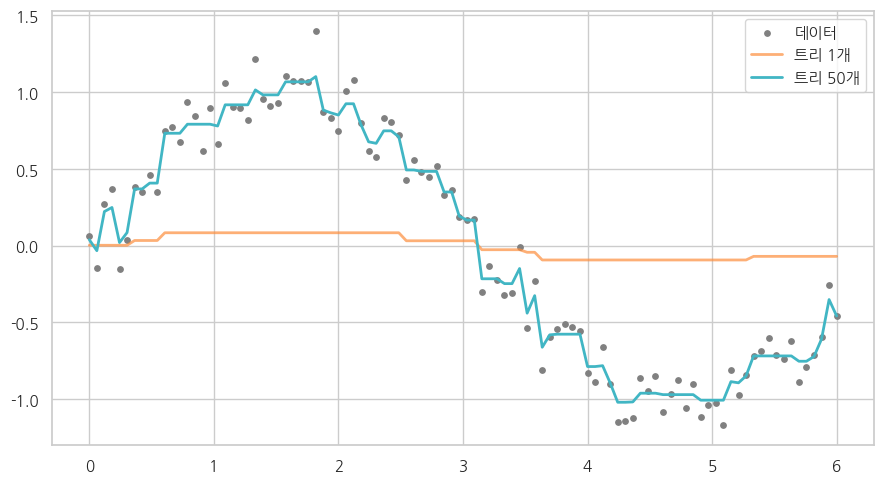

In [14]:
# ─────────────────────────────────────────────
# [C14] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 Gradient Boosting — 잔차를 순차로 보정
# ─────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=3, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
print(f"Gradient Boosting 테스트 정확도 = {gbm.score(Xc_te, yc_te):.3f}")

from sklearn.ensemble import GradientBoostingRegressor

rng = np.random.default_rng(RANDOM_STATE)
Xd = np.linspace(0, 6, 100).reshape(-1, 1)
yd = np.sin(Xd).ravel() + rng.normal(0, 0.2, 100)
plt.figure(figsize=(9, 5))
plt.scatter(Xd, yd, s=15, color="gray", label="데이터")
for n, c, a in [(1, "#fd8d3c", 0.7), (50, "#41b6c4", 1.0)]:
    g = GradientBoostingRegressor(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE).fit(Xd, yd)
    plt.plot(Xd, g.predict(Xd), color=c, alpha=a, lw=2, label=f"트리 {n}개")
plt.legend(); plt.tight_layout(); plt.show()

### XGBoost — 부스팅의 현대 챔피언

**XGBoost**는 GBM을 **정규화·고속화**한 구현으로, 정형 데이터 머신러닝 대회·실무의 사실상 표준입니다. GBM 대비 주요 차이:

- **내장 정규화(L1·L2·gamma):** 과적합을 손실 함수 차원에서 직접 억제(GBM엔 없음).
- **2차 정보 사용:** 기울기뿐 아니라 곡률(Hessian)까지 써 더 빠르게 수렴.
- **결측치 자동 처리·희소 데이터 인식·병렬화로 빠름.**

▶ 실행: [C15]

In [15]:
# ─────────────────────────────────────────────
# [C15] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 XGBoost — 정규화된 부스팅
# ─────────────────────────────────────────────
from xgboost import XGBClassifier

# reg_lambda = 잎 출력값에 거는 L2 패널티

xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                    reg_lambda=1.0, random_state=RANDOM_STATE, eval_metric="logloss")
xgb.fit(Xc_tr, yc_tr)
print(f"XGBoost 테스트 정확도 = {xgb.score(Xc_te, yc_te):.3f}")

# n_estimators와 max-depth를 Gradient Boosting과 동일하게 설정해도 정확도가 더 낮은 이유는 테스트셋이 114개라 샘플 1개 = 0.009이므로 이 격차는 노이즈에 해당함. 이 데이터는 작고 깨끗해 어떤 모델도 변별력이 없음(천장 효과).
# XGBoost의 강점(정규화·결측처리·속도)은 대용량·고차원·지저분한 데이터에서 발현됨.

XGBoost 테스트 정확도 = 0.947


정확도 한 숫자만으로는 *무엇을* 맞히고 틀렸는지 모릅니다. XGBoost의 **혼동행렬**을 보며 앞서 배운 평가를 이어가 봅시다(불균형·정밀도·재현율은 이후 본격적으로).

▶ 실행: [C16]

대각선이 정답. 이후 이 표로 정밀도·재현율을 계산합니다.


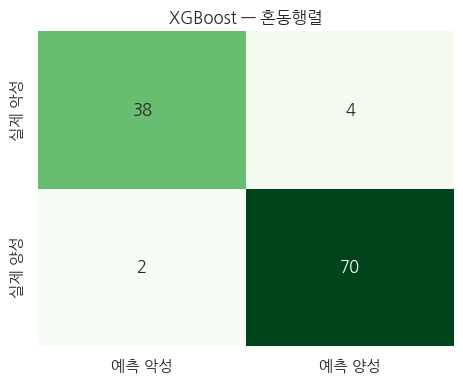

In [16]:
# [C16] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 XGBoost 혼동행렬 — 무엇을 맞히고 틀렸나
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(yc_te, xgb.predict(Xc_te))
fig, ax = plt.subplots(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["예측 악성", "예측 양성"], yticklabels=["실제 악성", "실제 양성"], ax=ax)
ax.set_title("XGBoost — 혼동행렬"); plt.tight_layout(); plt.show()
print("대각선이 정답. 이후 이 표로 정밀도·재현율을 계산합니다.")

학습률(`learning_rate`)은 부스팅의 가장 중요한 손잡이입니다. 값을 바꿔가며 성능이 어떻게 움직이는지 봅니다.

▶ 실행: [C17]

→ 너무 크면 불안정·과적합, 너무 작으면 더 많은 트리가 필요합니다(트레이드오프).


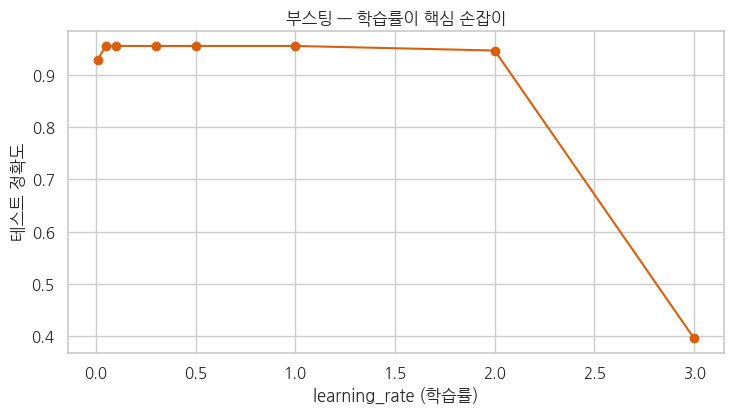

In [17]:
# ─────────────────────────────────────────────
# [C17] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 학습률(learning_rate)이 부스팅에 미치는 영향
# ─────────────────────────────────────────────
lrs = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 3.0]
acc_lr = [GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=3,
          random_state=RANDOM_STATE).fit(Xc_tr, yc_tr).score(Xc_te, yc_te) for lr in lrs]
plt.figure(figsize=(7.5, 4.3))
plt.plot(lrs, acc_lr, "o-", color="#d95f0e")
plt.xlabel("learning_rate (학습률)"); plt.ylabel("테스트 정확도")
plt.title("부스팅 — 학습률이 핵심 손잡이")
plt.tight_layout(); plt.show()
print("→ 너무 크면 불안정·과적합, 너무 작으면 더 많은 트리가 필요합니다(트레이드오프).")

> ⚠️ **[심화] Nice-to-Know:** LightGBM(leaf-wise 성장·대용량 고속)·CatBoost(범주형 특화)도 같은 부스팅 계열이고, XGBoost의 `early_stopping`(검증 점수가 안 오르면 조기 종료)·부스팅 손실 함수의 수식 유도는 *관심 있는 분*을 위한 심화입니다. 본문 학습엔 위 세 모델로 충분합니다.

## ⌨️ 백문이 불여일타! (4)

```
[문제]
지금까지 만든 5개 모델(단일트리·RF·AdaBoost·GBM·XGBoost)의 테스트 정확도를 한 줄씩 출력해 비교해보세요.
```

In [18]:
# [C18] ◀ Part 4 · ⌨️ 백문이 불여일타! (4) ⌨️ 백문이 불여일타! (4) — 다섯 모델 테스트 정확도 비교

print(f"단일 트리 정확도 = {tree.score(Xc_te, yc_te):.3f}")
print(f"랜덤포레스트 정확도 = {rf.score(Xc_te, yc_te):.3f}")
print(f"AdaBoost 테스트 정확도 = {ada.score(Xc_te, yc_te):.3f}")
print(f"Gradient Boosting 테스트 정확도 = {gbm.score(Xc_te, yc_te):.3f}")
print(f"XGBoost 테스트 정확도 = {xgb.score(Xc_te, yc_te):.3f}")

from sklearn.model_selection import cross_val_score
models = [("단일 트리", tree), ("랜덤포레스트", rf), ("AdaBoost", ada), ("Gradient Boosting", gbm), ("XGBoost", xgb)]

print("\n─── 5겹 교차검증 (전체 데이터) ───")
for name, m in models:
    s = cross_val_score(m, Xc, yc, cv=5)
    print(f"{name}: 평균 {s.mean():.3f} ± {s.std():.3f}")

단일 트리 정확도 = 0.939
랜덤포레스트 정확도 = 0.947
AdaBoost 테스트 정확도 = 0.965
Gradient Boosting 테스트 정확도 = 0.956
XGBoost 테스트 정확도 = 0.947

─── 5겹 교차검증 (전체 데이터) ───
단일 트리: 평균 0.919 ± 0.025
랜덤포레스트: 평균 0.961 ± 0.025
AdaBoost: 평균 0.977 ± 0.009
Gradient Boosting: 평균 0.963 ± 0.023
XGBoost: 평균 0.972 ± 0.010


<details>
<summary>(클릭) 💡 힌트</summary>

- 다섯 모델은 이미 학습되어 변수 `single`, `rf`, `ada`, `gbm`, `xgb`에 들어 있습니다 — 다시 학습할 필요 없이 `.score(Xc_te, yc_te)`만 부르면 됩니다.
- (이름, 모델) 튜플의 리스트를 만들어 `for` 반복문으로 돌리면 한 줄씩 깔끔하게 출력할 수 있습니다.

</details>

## 🚦 짚고 넘어가기

1. 배깅과 부스팅의 가장 큰 차이(병렬 vs 순차)를 설명해보세요.
2. Gradient Boosting에서 각 트리는 무엇을 예측하나요?
3. XGBoost가 GBM과 다른 점 하나를 들어보세요.

> 💡 **다음 Part 예고:** 앙상블로 성능을 얻었습니다. 그런데 **무엇을 내주었을까요?** 성능과 해석력의 트레이드오프, 그리고 피처 중요도를 봅니다.

# Part 5. 단일 vs 앙상블 · 피처 중요도

성능을 한자리에 모아 비교하고, 트리 계열의 큰 선물인 **피처 중요도**를 봅니다. 그리고 **성능 vs 해석력**의 트레이드오프를 정리합니다.

> ❓ **이 파트에서 답할 질문:** 앙상블로 성능을 얻는 대신 무엇을 내주며, 어떤 피처가 예측을 이끌까?

## 💡 쉽게 말하면 — 성적표와 영수증을 함께 보기

지금까지 네 종류의 모델을 만들었습니다. 이제 성적을 한자리에 모아 비교하고, **무엇을 지불했는지** 정산할 차례입니다.

성능만 보면 앙상블이 이깁니다. 그런데 값을 치릅니다 — **"왜 그렇게 예측했는지" 설명하기가 어려워집니다.** 단일 트리는 if-else로 읽히지만, 300그루의 투표 결과는 사람이 따라갈 수 없습니다.

그래서 이 Part는 두 가지를 함께 봅니다. 성적표(모델별 점수)와 영수증(해석력의 대가)입니다. 그리고 트리 계열이 주는 작은 보상 하나 — **피처 중요도**도 확인합니다.

## 🔍 자세히 알아보기 — 성능 vs 해석력, 무엇을 얻고 무엇을 내주나

| 모델 | 성능 | 해석력 | 안정성 |
|------|------|--------|--------|
| 단일 의사결정나무 | 보통 | **높음**(if-else로 읽힘) | 낮음 |
| 랜덤포레스트 | 높음 | 중간(중요도) | 높음 |
| XGBoost/GBM | **최고 수준** | 낮음(블랙박스) | 중간(튜닝 필요) |

> 🎯 **오늘의 핵심**
> 앙상블은 **성능을 올리는 대신 해석력을 내줍니다.** "왜 그렇게 예측했는지" 설명이 필요한 상황(금융·의료)에서는 이 트레이드오프를 신중히 따져야 해요. 블랙박스 모델을 *설명*하는 기법(SHAP)은 이후 배웁니다.

> ⚠️ **피처 중요도의 세 가지 한계 — 이후 SHAP이 채웁니다**
>
> 1. **방향을 모릅니다.** `feature_importances_`는 "이 피처가 중요하다"만 알려주고 **"값이 크면 생존 확률이 올라가는지 내려가는지"는 말해주지 않습니다.** 중요도는 항상 양수라 부호가 없습니다.
> 2. **개별 예측을 설명하지 못합니다.** 전체 평균으로 "중요했다"는 것이지, *이 고객 한 명*을 왜 그렇게 예측했는지는 답하지 못합니다.
> 3. **인과가 아닙니다.** "중요하다"는 *예측 기여*이지 *원인*이 아닙니다(지금까지 배운 "상관≠인과"와 같은 주의).
>
> 세 한계를 모두 메우는 도구가 **SHAP**이고, **모델 해석 시간**에 정면으로 다룹니다. 오늘은 "중요도는 첫 단서일 뿐"이라는 것까지 챕겨 가세요.

### 피처 중요도, 실무에서 이렇게 씁니다

피처 중요도는 단순한 호기심 충족이 아니라 **실무 도구**입니다.

- **피처 선택:** 중요도가 거의 0인 피처는 빼서 모델을 가볍고 빠르게(과적합↓). → 피처 엔지니어링과 연결.
- **모델 디버깅:** 말도 안 되는 피처(예: 고객 ID)가 1위라면 **데이터 누수**를 의심. ("미래 정보가 새어든 건 아닌가?")
- **이해관계자 설득:** "이탈에는 *최근 접속 빈도*와 *고객센터 문의 수*가 가장 크게 작용합니다" 같은 비즈니스 언어로 번역.
- **도메인 검증:** 중요한 피처가 현장 지식과 맞는지 점검 — 안 맞으면 모델이나 데이터를 다시 본다.

> ⚠️ 다시 강조: 중요도는 **예측 기여**이지 **인과**가 아닙니다. "이 피처를 바꾸면 결과가 바뀐다"는 보장이 아닙니다(인과추론과 구분).

### 실무 모델 선택 가이드 — 무엇부터 쓸까?

| 상황 | 추천 |
|------|------|
| 규칙을 사람에게 *설명*해야 함 | 단일 의사결정나무(얕게) |
| 빠르게 강한 베이스라인이 필요 | 랜덤포레스트(기본값) |
| 정확도를 최대한 짜내야 함(대회·핵심 모델) | XGBoost(+튜닝) |
| 매우 큰 데이터·빠른 학습 | LightGBM `[심화]` |
| 범주형 피처가 많음 | CatBoost `[심화]` |

> 💡 정형 데이터(표 형태)에서는 **여전히 트리 앙상블이 딥러닝보다 강한 경우가 많습니다.** "표 데이터엔 XGBoost부터"가 현업의 상식입니다.

### 성능 vs 해석력 — 실무에서 진짜 부딪히는 문제

성능 좋은 모델이 항상 정답은 아닙니다. 예를 들어:

- **은행 대출 거절:** 법적으로 "왜 거절했는지" 고객에게 설명해야 합니다. 블랙박스 XGBoost가 "거절"이라고만 하면 곤란합니다. → 해석 가능한 모델이나 SHAP 같은 설명 도구가 필요.
- **의료 진단 보조:** 의사가 모델의 판단 근거를 납득해야 신뢰하고 씁니다.
- **반대로 추천·광고 클릭 예측:** 설명보다 *정확도*가 훨씬 중요 → XGBoost 같은 고성능 모델이 적합.

> 🎯 그래서 모델 선택은 "가장 정확한 것"이 아니라 **"이 문제에 정확도와 설명가능성 중 무엇이 더 중요한가"** 를 먼저 묻는 데서 시작합니다. 이 균형 감각이 데이터 분석가의 핵심 역량입니다. 블랙박스를 *사후에* 설명하는 SHAP 기법은 이후 배웁니다.

## 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에

> 🤔 **예상해 볼까요?** 네 모델(단일 트리·랜덤포레스트·XGBoost·AdaBoost)의 테스트 정확도 순위를 예상해보세요. 그리고 **피처 중요도 상위에 어떤 종류의 피처**가 올 것 같습니까? (유방암 진단 데이터입니다)

▶ 실행: [C19]

→ 앙상블(특히 부스팅)이 단일 트리보다 대체로 높고 안정적입니다.

랜덤포레스트 피처 중요도 상위 5개
worst perimeter         0.137344
worst area              0.137312
worst concave points    0.115502
mean concave points     0.091774
worst radius            0.084111


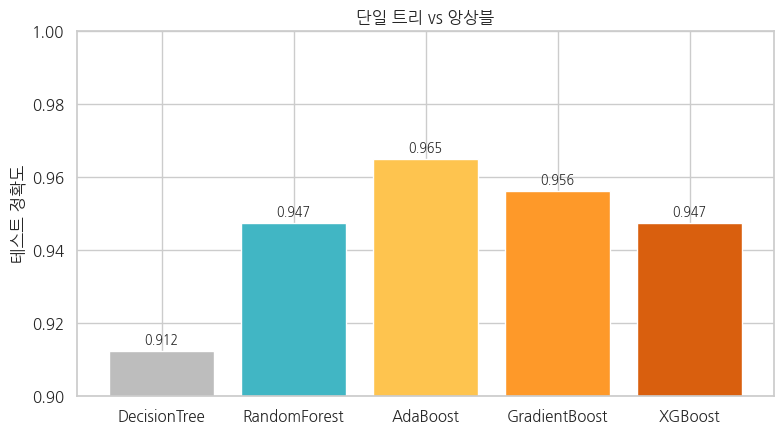

In [19]:
# ─────────────────────────────────────────────
# [C19] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 모델별 테스트 정확도 비교
# ─────────────────────────────────────────────
names = ["DecisionTree", "RandomForest", "AdaBoost", "GradientBoost", "XGBoost"]
models = [single, rf, ada, gbm, xgb]
accs = [m.score(Xc_te, yc_te) for m in models]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(names, accs, color=["#bdbdbd", "#41b6c4", "#fec44f", "#fe9929", "#d95f0e"])
plt.ylim(0.9, 1.0); plt.ylabel("테스트 정확도")
plt.title("단일 트리 vs 앙상블")
for b, a in zip(bars, accs):
    plt.text(b.get_x()+b.get_width()/2, a+0.002, f"{a:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("→ 앙상블(특히 부스팅)이 단일 트리보다 대체로 높고 안정적입니다.")

imp = pd.Series(rf.feature_importances_, index=Xc.columns).sort_values(ascending=False)
print("\n랜덤포레스트 피처 중요도 상위 5개")
# worst perimeter         윤곽선 길이
# worst area              면적
# worst concave points    세포핵의 오목점 개수
# mean concave points     평균적 윤곽 불규칙
# worst radius            반경
print(imp.head(5).to_string())

> 🎯 **[C19] 예상과 맞았나요?** 앙상블이 단일 트리를 앞서는 것은 예상대로입니다. 그런데 **피처 중요도 상위**를 보세요 — 종양의 크기·모양과 관련된 피처들이 올라옵니다. 의학 지식과 맞아떨어지는 결과이고, 이렇게 **도메인 상식과 대조하는 것**이 중요도를 읽는 첫 단계입니다.

### 결정경계로 보는 차이 — 단일 트리 vs 앙상블

같은 두 피처로 단일 트리·랜덤포레스트·XGBoost의 **결정경계**를 나란히 그려 봅시다. 앙상블이 어떻게 단일 트리의 들쭉날쭉함을 *부드럽게* 만드는지 한눈에 보입니다.

▶ 실행: [C20]

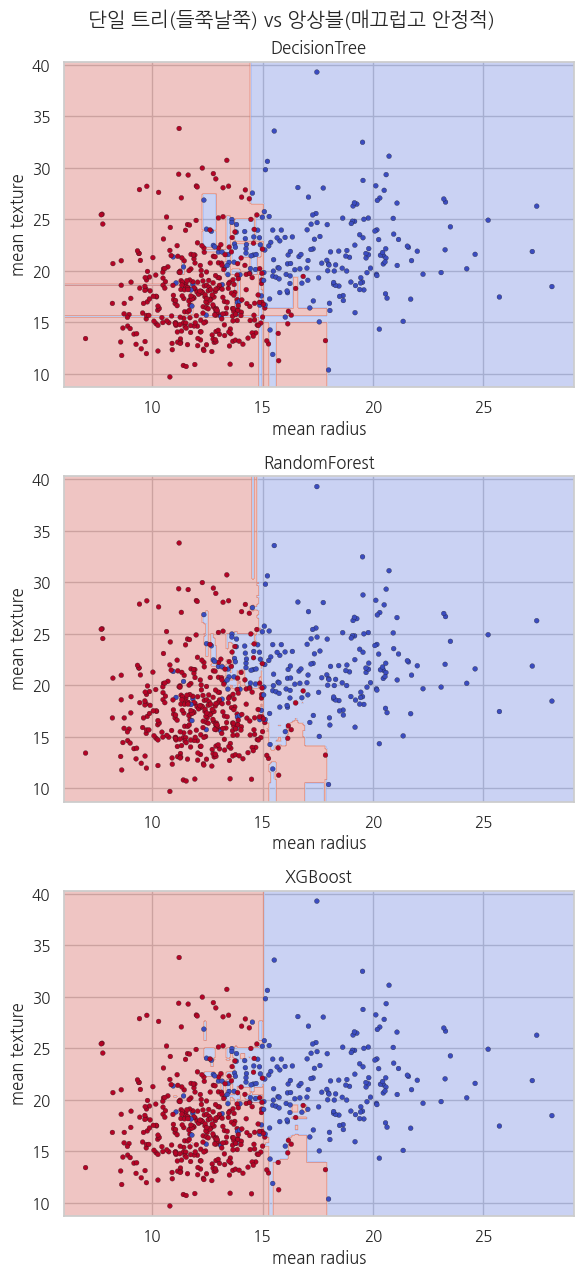

In [20]:
# ─────────────────────────────────────────────
# [C20] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 결정경계 비교 — Tree / RandomForest / XGBoost
# ─────────────────────────────────────────────
import numpy as np
feats = ["mean radius", "mean texture"]
X2 = Xc[feats].values
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

models2 = [("DecisionTree", DecisionTreeClassifier(max_depth=None, random_state=42)),
           ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
           ("XGBoost", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                                     random_state=42, eval_metric="logloss"))]
fig, axes = plt.subplots(3, 1, figsize=(6, 13))
for ax, (name, m) in zip(axes, models2):
    m.fit(X2, yc)
    zz = m.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2[:,0], X2[:,1], c=yc, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(name); ax.set_xlabel(feats[0]); ax.set_ylabel(feats[1])
plt.suptitle("단일 트리(들쭉날쭉) vs 앙상블(매끄럽고 안정적)")
plt.tight_layout(); plt.show()

> **[C20] 읽는 법:** 단일 트리는 경계가 **각지고 과적합**돼 보이지만, 랜덤포레스트·XGBoost는 여러 나무를 종합해 **더 부드럽고 일반화된 경계**를 만듭니다. 같은 데이터인데 "여러 모델을 모으면" 경계가 안정되는 걸 눈으로 확인할 수 있습니다. 이것이 오늘의 핵심 — **"여러 모델을 모으면 더 강해진다."**

▶ 실행: [C21]

가장 중요한 피처 Top 3:
worst perimeter         0.137344
worst area              0.137312
worst concave points    0.115502
dtype: float64


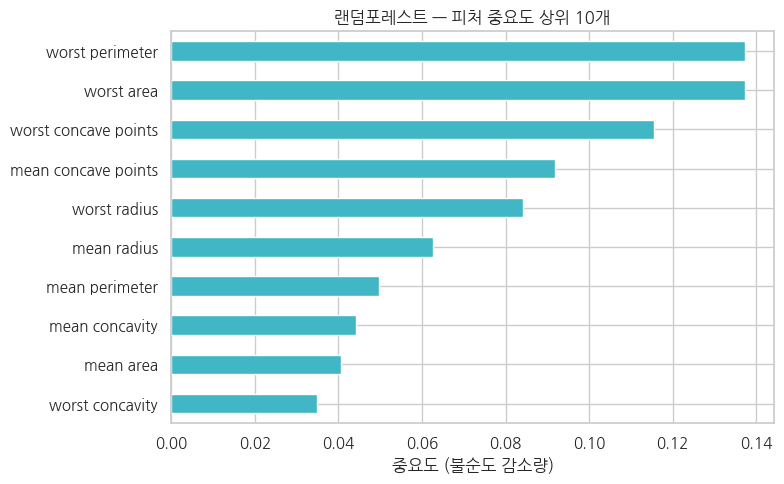

In [21]:
# ─────────────────────────────────────────────
# [C21] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 피처 중요도 — 어떤 피처가 예측을 이끄는가 (랜덤포레스트)
# ─────────────────────────────────────────────
imp = pd.Series(rf.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
imp[::-1].plot(kind="barh", color="#41b6c4")
plt.title("랜덤포레스트 — 피처 중요도 상위 10개")
plt.xlabel("중요도 (불순도 감소량)")
plt.tight_layout(); plt.show()
print("가장 중요한 피처 Top 3:")
print(imp.head(3))

> **[C21] 읽는 법:** 막대가 길수록 그 피처가 분할에 많이 기여했다는 뜻입니다. 단, 이 "불순도 기반 중요도(MDI)"는 값 종류가 많은 피처에 **편향**될 수 있습니다. 더 신뢰도 높은 **순열 중요도(Permutation Importance)** 와 비교해 봅시다.

▶ 실행: [C22]

In [22]:
# ─────────────────────────────────────────────
# [C22] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 순열 중요도 — 피처를 섞으면 성능이 얼마나 떨어지나
# ─────────────────────────────────────────────
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, Xc_te, yc_te, n_repeats=10, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=Xc.columns).sort_values(ascending=False).head(5)
print("순열 중요도 Top 5 (섞었을 때 정확도 하락폭):")
print(perm_imp.round(4))
print("\n→ 불순도 기반과 순열 기반의 순위를 비교해 보세요. 대체로 비슷하지만 다를 수 있습니다.")

순열 중요도 Top 5 (섞었을 때 정확도 하락폭):
mean concave points       0.0026
mean radius               0.0000
mean fractal dimension    0.0000
radius error              0.0000
mean area                 0.0000
dtype: float64

→ 불순도 기반과 순열 기반의 순위를 비교해 보세요. 대체로 비슷하지만 다를 수 있습니다.


## ⌨️ 백문이 불여일타! (5)

```
[문제]
1) 불순도 기반 중요도(feature_importances_)와 순열 중요도(permutation_importance)의 Top 5 피처 순위가 같은지 비교해보세요.
2) 순위가 다르다면 왜 그럴지 생각해보세요.
```

In [23]:
# [C23] ◀ Part 5 · ⌨️ 백문이 불여일타! (5) ⌨️ 백문이 불여일타! (5) — 두 중요도의 Top 5 비교

pd.set_option("display.unicode.east_asian_width", True)

top_i = imp.sort_values(ascending=False).head(5)
top_p = perm_imp.sort_values(ascending=False).head(5)

compare = pd.DataFrame({
    "불순도 피처": top_i.index,
    "불순도 값": top_i.values.round(4),
    "순열 피처": top_p.index,
    "순열 값": top_p.values.round(4),
}, index=[f"{i}위" for i in range(1, 6)])

print("두 중요도 Top 5 비교")
display(compare)

두 중요도 Top 5 비교
              불순도 피처  불순도 값               순열 피처  순열 값
1위       worst perimeter     0.1373     mean concave points   0.0026
2위            worst area     0.1373             mean radius   0.0000
3위  worst concave points     0.1155  mean fractal dimension   0.0000
4위   mean concave points     0.0918            radius error   0.0000
5위          worst radius     0.0841               mean area   0.0000


In [24]:
# 불순도 중요도는 학습 과정에서 트리가 그 피처를 얼마나 자주·유용하게 사용했는지를 측정함.
# 순열 중요도는 그 피처를 망가뜨렸을 때 예측 성능이 얼마나 떨어지는지를 측정함.

# 예측 기여도와 인과는 다름.

# 역인과를 고려해야 함. worst area(세포핵 크기)가 높은 중요도를 차지하여 이것을 통해 유방암 진단은 가능하나, 유방암이 -> 세포핵의 크기에 인과를 미치므로 세포핵의 크기 자체가 유방암의 원인이 될 수 없음.

# 상관 피처(radius·perimeter·area)끼리 중요도가 분산될 수 있음.
# - 불순도 기반 중요도: 트리가 둘 중 아무거나 골라 쓸 수 있어 중요도가 여러 피처로 나뉘어 배분될 수 있음.
# - 순열 중요도: 한 피처를 섞어 망가뜨려도 상관된 다른 피처가 비슷한 정보를 대신 제공하므로 각 피처의 중요도가 실제보다 작게 나타날 수 있음.
# - 즉, 불순도 기반은 대체 가능한 피처가 있으면 나눠 갖고 순열은 0에 가까워져 순위가 갈림.
# - 중요도가 낮은 게 원인이 아니라는 것을 의미하지는 않음. 상관행렬을 먼저 봐야 함.

[기준] radius 혼자일 때 — 불순도 0.1151 / 순열 0.0145
[불순도] 셋이 함께 — 0.0639 / 0.1213 / 0.0929   (합 0.2782)
[순열]   셋이 함께 — 0.0048 / 0.0101 / 0.0118


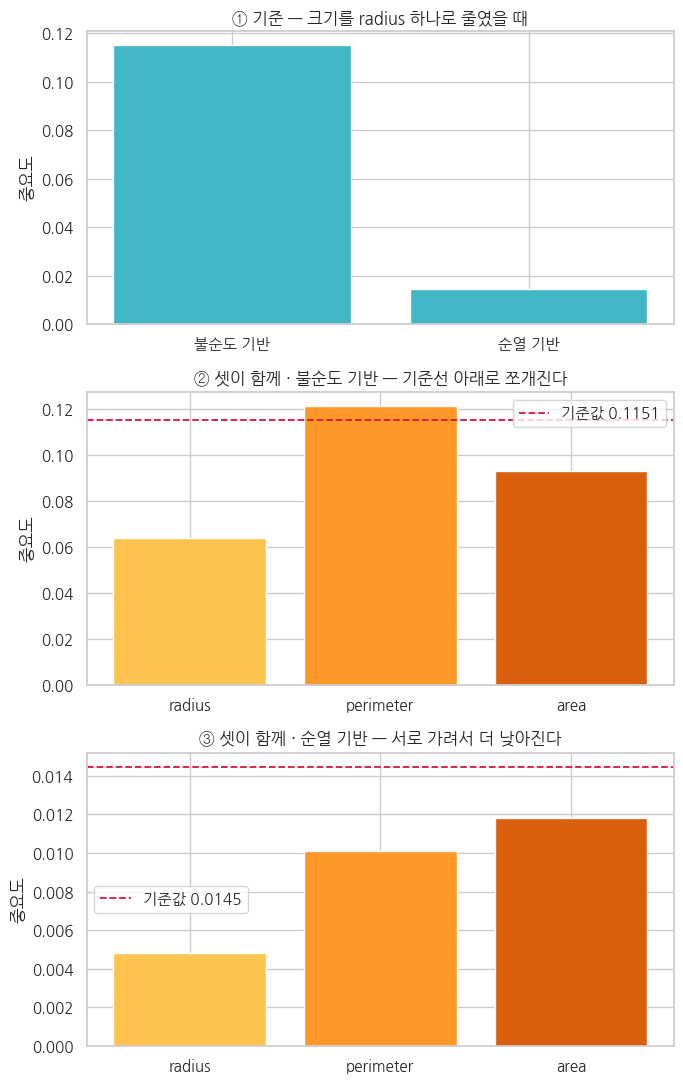

In [25]:
# [실험] 상관 피처(radius·perimeter·area)가 중요도를 어떻게 나눠 갖는가
from sklearn.inspection import permutation_importance

SIZE3  = ["mean radius", "mean perimeter", "mean area"]                       # 관찰 대상
OTHERS = ["radius error", "perimeter error", "area error",
          "worst radius", "worst perimeter", "worst area"]                    # 크기 친척 → 양쪽에서 제거

Xbase = Xc.drop(columns=OTHERS)                               # 24열
XA    = Xbase.drop(columns=["mean perimeter", "mean area"])   # 22열 · 크기 = radius 하나
XB    = Xbase                                                 # 24열 · 크기 = 셋 다

XA_tr, XA_te, y_tr, y_te = train_test_split(XA, yc, test_size=0.2, random_state=RANDOM_STATE)
XB_tr, XB_te, _,    _    = train_test_split(XB, yc, test_size=0.2, random_state=RANDOM_STATE)

rfA = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(XA_tr, y_tr)
rfB = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(XB_tr, y_tr)

# 불순도 기반
iA = pd.Series(rfA.feature_importances_, index=XA.columns)
iB = pd.Series(rfB.feature_importances_, index=XB.columns)
i_base = iA["mean radius"]
i_vals = [iB[f] for f in SIZE3]

# 순열 기반 (모델이 안 본 테스트셋에서 측정)
rA = permutation_importance(rfA, XA_te, y_te, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
rB = permutation_importance(rfB, XB_te, y_te, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
pA = pd.Series(rA.importances_mean, index=XA.columns)
pB = pd.Series(rB.importances_mean, index=XB.columns)
p_base = pA["mean radius"]
p_vals = [pB[f] for f in SIZE3]

print(f"[기준] radius 혼자일 때 — 불순도 {i_base:.4f} / 순열 {p_base:.4f}")
print(f"[불순도] 셋이 함께 — {i_vals[0]:.4f} / {i_vals[1]:.4f} / {i_vals[2]:.4f}   (합 {sum(i_vals):.4f})")
print(f"[순열]   셋이 함께 — {p_vals[0]:.4f} / {p_vals[1]:.4f} / {p_vals[2]:.4f}")

bars = ["radius", "perimeter", "area"]
cols = ["#fec44f", "#fe9929", "#d95f0e"]

fig, axes = plt.subplots(3, 1, figsize=(7, 11))

axes[0].bar(["불순도 기반", "순열 기반"], [i_base, p_base], color="#41b6c4")
axes[0].set_title("① 기준 — 크기를 radius 하나로 줄였을 때")

axes[1].bar(bars, i_vals, color=cols)
axes[1].axhline(i_base, ls="--", color="crimson", lw=1.3, label=f"기준값 {i_base:.4f}")
axes[1].legend(); axes[1].set_title("② 셋이 함께 · 불순도 기반 — 기준선 아래로 쪼개진다")

axes[2].bar(bars, p_vals, color=cols)
axes[2].axhline(p_base, ls="--", color="crimson", lw=1.3, label=f"기준값 {p_base:.4f}")
axes[2].legend(); axes[2].set_title("③ 셋이 함께 · 순열 기반 — 서로 가려서 더 낮아진다")

for ax in axes:
    ax.set_ylabel("중요도")
plt.tight_layout(); plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- 불순도 기반은 `rf.feature_importances_`를 `pd.Series(..., index=Xc.columns)`로 감싸고 `sort_values`로 정렬하면 Top 5를 뽑을 수 있습니다.
- 순열 중요도는 [C22]에서 만든 `perm_imp`를 그대로 재사용하면 됩니다.
- 두 순위를 `.head(5)`와 `.index.tolist()`로 뽑아 나란히 출력해 비교해보세요.

</details>

## 🚦 짚고 넘어가기

1. 단일 트리와 XGBoost는 성능·해석력에서 각각 어떤 위치인가요?
2. 불순도 기반 중요도의 약점은 무엇인가요?
3. "피처 중요도가 높다 = 그 피처가 원인이다"는 옳은가요?

> 💡 **다음 Part 예고:** 배운 모델들을 한 흐름으로 묶어, 트리→RF→XGBoost를 비교하는 **모델 카드 v0.2**를 만들어 봅니다.

# 🎓 오늘의 정리

## 개념 연결 한눈에

```text
[단일 의사결정나무]  질문으로 나눔(지니·정보획득) — 해석 쉬움, 불안정·과적합
   │  한 그루로는 부족
   ├─ [배깅/랜덤포레스트]  독립 나무들의 투표 — 분산↓, 안정적 (병렬)
   └─ [부스팅 AdaBoost·GBM·XGBoost]  오차 순차 보정 — 편향↓, 최고 성능 (순차)
   │
[피처 중요도]  무엇이 예측을 이끄나 (단, 인과 아님)
   │  성능 ↔ 해석력 트레이드오프
   ▼
 이 성능, 믿어도 될까? — 과적합·규제·불균형 평가
```

## 한 장 정리

| 개념 | 한 줄 요약 |
|------|-----------|
| 의사결정나무 | 정보획득이 큰 질문으로 분기. 해석 쉬우나 과적합·불안정 |
| 가지치기 | `max_depth`·`min_samples_leaf` 등으로 과적합 억제 |
| 배깅/RF | 부트스트랩 표본 + 독립 나무 투표 → 분산↓ (병렬) |
| 부스팅 | 앞 모델의 오차를 순차 보정 → 편향↓ (AdaBoost·GBM·XGBoost) |
| GBM 핵심 | 잔차를 예측하는 트리를 학습률만큼 더해 감 |
| XGBoost | 정규화·2차정보·결측처리로 빠르고 강한 부스팅 |
| 피처 중요도 | 예측 기여도(불순도/순열). 인과는 아님 |
| 트레이드오프 | 앙상블은 성능↑·해석력↓ |

## 진단 → 다음 도구 매핑

| 신호 | 다음 도구 |
|------|-----------|
| 정확도가 높아도 불균형에 속는다 | 정밀도·재현율·PR곡선 |
| 과적합/격차가 크다 | 규제·교차검증 |
| 성능을 더 짜내고 싶다 | 피처 엔지니어링·하이퍼파라미터 튜닝 |
| 블랙박스를 설명해야 한다 | SHAP 모델 해석 |

### ✅ 예측 모델 워크플로 체크리스트 (오늘 배운 것 종합)

새 예측 문제를 만나면 이 순서로 점검하세요.

- [ ] **문제 유형** 확인 — 회귀? 분류? (타겟이 숫자/범주)
- [ ] **train/test 분리** — `stratify`(분류), `random_state` 고정
- [ ] **베이스라인** 먼저 — `DummyClassifier`/`DummyRegressor`
- [ ] **랜덤포레스트** 돌려 베이스라인 성능 확보(기본값)
- [ ] 더 필요하면 **XGBoost** + 튜닝
- [ ] **학습 vs 테스트 격차**로 과적합 점검
- [ ] **피처 중요도**로 무엇이 예측을 이끄는지 해석 + 누수 점검
- [ ] 결과를 **모델 카드**에 기록 (문제·데이터·성능·한계)

> 이 체크리스트가 앞으로 모든 ML 과제의 출발 템플릿입니다. 이후 이를 **Pipeline 코드**로 자동화합니다.

## ⚠️ 오늘의 흔한 오해 모음

- **"앙상블은 항상 단일 모델보다 좋다"** → 대체로 그렇지만 항상은 아닙니다. 데이터가 아주 단순하거나 작으면 단순 모델이 더 나을 수도, 과한 부스팅이 과적합할 수도 있습니다. **그래서 늘 테스트 점수로 확인**합니다.
- **"트리 수(`n_estimators`)는 많을수록 좋다"** → 랜덤포레스트는 안정되지만 비용↑, 부스팅은 **너무 많으면 과적합**.
- **"XGBoost가 최고니 무조건 이것만 쓰면 된다"** → 해석이 필요하거나, RF로 충분하거나, 데이터가 작으면 아닙니다. **문제에 맞는 선택**이 먼저.
- **"피처 중요도 1위 = 가장 중요한 원인"** → 예측 기여일 뿐 인과가 아니며, 누수 신호일 수도 있습니다.

> 💡 이 오해들의 공통 해독제는 하나 — **"숫자 하나로 판단하지 말고, 테스트로 확인하고 맥락을 함께 보라."** 이후 이 태도를 평가지표로 더 단단히 만듭니다.

## 이 모듈 안에서 오늘의 위치

```text
단일 모델(선형·로지스틱 회귀)         — 예측의 첫걸음
  │
앙상블(트리·RF·부스팅)  ← 오늘        — 성능을 끌어올리다
  │
과적합·규제·불균형 평가                — "이 성능 믿어도 될까?"
  │
피처 엔지니어링 · 튜닝            — 입력·설정 개선
  │
모델 해석(SHAP)                        — 블랙박스를 설명
```

오늘 만든 강한 모델들은 **정확도는 높지만 두 가지 숙제**를 남겼습니다 — (1) "이 정확도가 불균형에 속은 건 아닌가, 과적합은 아닌가?", (2) "왜 그렇게 예측했나?". 다음 시간들이 이 숙제를 하나씩 풉니다. 오늘은 **무기를 갖췄고**, 앞으로 그 무기를 **검증하고 설명하는** 법을 배웁니다.

## 🙋 자주 묻는 질문 (FAQ)

**Q1. 랜덤포레스트와 XGBoost 중 무엇을 먼저 써야 하나요?**
A. **랜덤포레스트를 베이스라인**으로 먼저 돌려보세요(튜닝 거의 불필요, 안정적). 더 성능을 짜내야 하면 XGBoost로 넘어가 튜닝합니다.

**Q2. 트리 계열은 스케일링(표준화)이 필요한가요?**
A. **대체로 불필요**합니다. 트리는 "크기"가 아니라 "분기 기준(크다/작다)"으로 나누기 때문에 단위에 둔감합니다. (반대로 로지스틱·KNN은 스케일링이 중요했습니다.)

**Q3. `n_estimators`는 클수록 좋은가요?**
A. 랜덤포레스트는 많을수록 *안정*되지만 어느 선부터 이득이 미미하고 느려집니다. 부스팅은 **너무 많으면 과적합**할 수 있어 학습률과 함께 조절합니다.

## 🎛️ 트리 계열 하이퍼파라미터 치트시트

처음엔 외울 필요 없습니다. "과적합이면 단순하게, 과소적합이면 복잡하게"라는 방향만 기억하세요.

| 파라미터 | 어떤 모델 | 과적합일 때 | 과소적합일 때 |
|----------|-----------|-------------|---------------|
| `max_depth` | 전부 | 줄인다 ↓ | 늘린다 ↑ |
| `min_samples_leaf` | 트리/RF | 늘린다 ↑ | 줄인다 ↓ |
| `n_estimators` | RF/부스팅 | (RF) 영향 적음 / (부스팅) 줄이거나 학습률↓ | 늘린다 ↑ |
| `learning_rate` | 부스팅 | 줄인다 ↓ (대신 트리↑) | 늘린다 ↑ |
| `max_features` | RF | 줄인다 ↓ (다양성↑) | 늘린다 ↑ |
| `reg_lambda`/`gamma` | XGBoost | 늘린다 ↑ (규제 강화) | 줄인다 ↓ |

> 💡 이 표의 **체계적 탐색법(Grid/Random Search·교차검증)** 이 바로 **하이퍼파라미터 튜닝**의 주제입니다. 오늘은 "이런 손잡이들이 있고, 방향이 이렇다" 정도면 충분합니다.

**Q4. 트리 앙상블도 결측치(빈 값)를 처리해야 하나요?**
A. 랜덤포레스트(sklearn)는 결측치를 자동 처리하지 못해 채워줘야 하지만, **XGBoost는 결측치를 자동으로 처리**합니다(어느 쪽 가지로 보낼지 학습). 그래도 *왜 비었는지* 이해하고 전처리하는 습관이 우선입니다.

**Q5. 피처 스케일링을 안 해도 정말 괜찮나요?**
A. 네, 트리 계열은 "크다/작다"의 순서만 쓰기 때문에 스케일에 둔감합니다. 다만 로지스틱·KNN·SVM 등 거리·계수 기반 모델에는 스케일링이 중요합니다(앞서 로지스틱에 StandardScaler를 쓴 이유). **모델에 따라 전처리가 다르다**는 것 자체가 중요한 교훈입니다.

## 📖 핵심 용어 사전

| 용어 | 한 줄 정의 |
|------|-----------|
| 불순도(Gini/Entropy) | 노드가 얼마나 섞였나(작을수록 순수) |
| 정보획득(IG) | 분할로 줄어든 불순도 |
| 가지치기(Pruning) | 깊이·잎 제한으로 과적합 억제 |
| 앙상블 | 약한 모형을 모아 강한 모형으로 |
| 배깅 | 부트스트랩 표본 + 독립 학습 + 집계(병렬) |
| 랜덤포레스트 | 트리로 배깅 + 피처 무작위 선택 |
| 부스팅 | 오차를 순차 보정(AdaBoost·GBM·XGBoost) |
| 학습률(η) | 부스팅이 한 번에 보정하는 크기 |
| 피처 중요도 | 피처의 예측 기여도(인과 아님) |

## 오늘 익힌 sklearn / xgboost 공통 패턴

모델 이름만 바꾸면 그대로 재사용됩니다 — 앞서 배운 `fit → predict → score` 골격이 앙상블에서도 똑같습니다.

```python
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

model = RandomForestClassifier(n_estimators=300, random_state=42)  # 또는 XGBClassifier(...)
model.fit(X_train, y_train)              # 학습
pred  = model.predict(X_test)            # 예측
score = model.score(X_test, y_test)      # 평가(정확도)
imp   = model.feature_importances_       # 보너스: 피처 중요도
```

> 💡 단일 모델이든 앙상블이든 **인터페이스가 같다**는 것이 scikit-learn의 큰 장점입니다. 그래서 여러 모델을 *똑같은 코드 틀*로 빠르게 비교할 수 있습니다(오늘 Part 5가 바로 그것).

> 💡 **다음 시간 예고:** 오늘 우리는 모델을 바꿔 점수를 올렸습니다. 그런데 그 점수는 **데이터를 한 번 나눠서** 얻은 것입니다. 나누는 방식을 바꾸면 점수가 어떻게 될까요? 다음 시간에는 시드만 바꿔 같은 실험을 열 번 반복해 **점수가 얼마나 흔들리는지** 직접 봅니다. 그리고 오늘 목격한 "학습 점수 1.000, 테스트는 정체"라는 과적합 증상을 **편향-분산**으로 설명하고, **교차검증**으로 정직하게 재는 법을 배웁니다. 오늘의 질문을 하나 남겨 두세요 — *"이 점수, 진짜일까?"*

# ❓ 오늘의 퀴즈

배운 내용을 잠깐 확인해보겠습니다. 틀려도 괜찮습니다.

## 개념 퀴즈
1. 배깅과 부스팅의 학습 방식 차이(병렬/순차)를 한 문장으로 설명하세요.
2. Gradient Boosting의 각 트리는 무엇을 예측하나요?
3. 트리 계열에 표준화가 대체로 불필요한 이유는?
4. "성능이 가장 높은 XGBoost를 항상 써야 한다"는 맞는 말일까요?

## 코드 퀴즈
빈칸을 채워, 유방암 데이터에 랜덤포레스트를 학습하고 테스트 정확도를 출력하세요.

In [26]:
# [C24] ◀ ❓ 오늘의 퀴즈 · 코드 퀴즈 코드 퀴즈 — 랜덤포레스트 학습과 테스트 정확도(빈칸 채우기)

# 여기에 코드를 작성하세요 — 빈칸(____)을 채워 완성해보세요
from sklearn.ensemble import RandomForestClassifier
quiz = RandomForestClassifier(n_estimators=200, random_state=42)
quiz.fit(Xc_tr, yc_tr)
print("테스트 정확도:", quiz.score(Xc_te, yc_te))

테스트 정확도: 0.956140350877193


# 📝 오늘의 과제

## 🧪 실습 노트북

오늘의 도구를 실제 비즈니스 데이터에 적용해 **모델 카드 v2**를 완성하는 실습은 **실습 노트북**에서 진행합니다. 개념이 정리됐다는 느낌이 들면 실습으로 넘어가세요.

실습에서 하는 일은 이렇습니다.

1. `DummyClassifier`·`DecisionTree`·`RandomForest`·`XGBoost`의 **4단 비교표** 작성
2. 각 모델의 **학습-테스트 격차**를 함께 기록해 과적합 진단
3. 랜덤포레스트 **피처 중요도 Top 10**을 그리고, 상위 3개를 비즈니스 언어로 해석
4. 위 결과를 **모델 카드 v2**로 정리

## 📝 미니과제 — 모델 카드 v2

**모델 카드 v2 규격** (앞 시간의 v1에 굵은 항목이 추가됩니다)

```markdown
## 모델 카드 v2 — {문제 이름}
- 데이터: {출처 / 크기 / 타깃 비율}
- 문제 유형: 분류 / 회귀
- **베이스라인: DummyClassifier(most_frequent) = {값}**   ← 이보다 나아야 모델
- **비교한 모델 4종: Dummy / Tree / RandomForest / XGBoost**
- 평가 지표 & 이유: {지표}를 쓴 이유
- **성능 비교표: 모델별 학습 점수 / 테스트 점수 / 격차**
- 과적합 진단: {가장 격차가 큰 모델과 그 해석}
- **선택한 모델과 근거: {왜 그것인가 — 성능·해석력·비용 중 무엇을 우선했나}**
- **피처 중요도 상위 3개와 해석: {비즈니스 언어로}**
- **중요도의 한계 명시: 방향성 부재 / 개별 설명 불가 / 인과 아님**
- 한계 & 다음 단계: {한 줄}
```

**평가 기준**

| 축 | 기준 |
| --- | --- |
| 비교의 완전성 | 베이스라인을 포함한 4단 비교가 있는가 |
| 진단 정확성 | 학습-테스트 격차로 과적합을 짚었는가 |
| 근거성 | 모델 선택 이유가 성능·해석력·비용 중 무엇인지 밝혔는가 |
| 정직성 | 피처 중요도의 한계를 함께 적었는가 |

**제출:** 개인 공개 저장소 main에 커밋·푸시하고 저장소·커밋 링크를 제출하세요.

> 📌 **실무 포인트:** 모델 카드에서 가장 자주 빠지는 항목이 **베이스라인**과 **선택 근거**입니다. "XGBoost가 제일 높아서 골랐다"는 근거가 아닙니다 — 해석이 필요한 자리인지, 학습 시간이 제약인지, 0.01의 성능 차이가 비즈니스에 의미가 있는지까지 말해야 근거입니다.

오늘 앙상블로 **정확도**를 끌어올렸습니다. 그런데 그 정확도를 **얼마나 믿을 수 있을까요?**

한 그루의 나무에서 숲과 부스팅까지, 정형 데이터 머신러닝의 *주력 무기*를 손에 넣으셨습니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

> 🎯 **오늘의 핵심:** *"한 그루는 약하고 불안정하지만, 잘 모으면(투표·보정) 강하고 안정적인 숲이 된다."* — 이 단순한 직관이 정형 데이터 ML을 지배하는 랜덤포레스트와 XGBoost의 전부입니다. 다음 시간엔 이 강한 모델의 성능을 *의심하고 검증하는* 법을 배웁니다.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>